# Исследование исходных данных и отбор выборки

## Контекст

Задача проекта - прогноз числа гостей ресторана на 7 дней вперед. В качестве данных используется открытый датасет **Rossmann Store Sales** (Kaggle): дневные продажи и число покупателей 1115 магазинов сети Rossmann за период с 1 января 2013 года по 31 июля 2015 года. Магазины выступают аналогом ресторанов: число покупателей за день (`Customers`) соответствует числу гостей - целевой переменной, дневная выручка (`Sales`) — выручке ресторана, а их отношение — среднему чеку.

Датасет выбран потому, что в нем есть все, что требуется для задачи: больше двух лет дневных наблюдений, недельная и годовая сезонность, праздники, промоакции, дни закрытия и реальные пропуски в данных.

## Цель ноутбука

Исходный датасет слишком велик для детального анализа каждого временного ряда - в нем больше миллиона строк. Поэтому детальный анализ и моделирование проводятся на **выборке магазинов**. Однако отбор делается не вслепую: сначала изучается вся сеть, и только затем по правилам, выведенным из данных, отбираются магазины.

В этом ноутбуке:
1. проверяется качество исходных данных: покрытие календаря, типы колонок, пропуски в выгрузке и в характеристиках магазинов;
2. фиксируется дизайн разбиения на обучающий и отложенный период - до отбора магазинов, чтобы отбор не использовал информацию из будущего;
3. разбираются закрытия магазинов и три вида пропусков: закрытый день, сбой выгрузки и период, когда точки нет;
4. каждый магазин описывается профилем: масштаб, средний чек, вариативность потока, рост год к году, режим работы, пропуски, характеристики из `store.csv`;
5. по профилю выделяются сегменты и признаки для стратификации, после чего собирается выборка;
6. выборка проверяется на соответствие критериям ниже.

## Каким критериям должна отвечать выборка

* **Полнота явлений.** В выборке должно быть все, что нужно для анализа: недельная и годовая сезонность, тренд, праздничные всплески, все три вида пропусков (закрытый день, сбой выгрузки, точки нет в этот период), аномалии и выбросы. Если какого-то явления в выборке нет, его нельзя показать в анализе и нельзя проверить, что модель с ним справляется.
* **Представительность.** Выводы и метрики на выборке должны переноситься на типичный магазин сети. Выборка должна быть не хуже простой случайной выборки того же размера по ключевым характеристикам: масштаб, средний чек, вариативность, рост, тип магазина, ассортимент, промоакции, конкуренция.
* **Представленность сегментов.** В каждом сегменте магазинов должно хватать, чтобы считать метрики не только в целом, но и по группам.
* **Честная оценка на отложенном периоде.** При отборе не используется целевая переменная в отложенном периоде. Магазины, закрытые на ремонт в этот период, исключаются: прогнозировать закрытую точку бессмысленно.
* **Воспроизводимость.**

## Описание признаков

**train.csv** - дневные наблюдения по магазинам (1 017 209 строк)
* `Store` - идентификатор магазина
* `DayOfWeek` - день недели (1 - понедельник, 7 - воскресенье)
* `Date` - дата наблюдения
* `Sales` - выручка магазина за день (валюта в датасете не указана)
* `Customers` - число покупателей за день; **целевая переменная** (аналог числа гостей)
* `Open` - был ли магазин открыт в этот день: 0 - закрыт, 1 - открыт
* `Promo` - проводилась ли в магазине в этот день промоакция: 0 - нет, 1 - да
* `StateHoliday` - государственный праздник: `a` - общий праздник, `b` - Пасха, `c` - Рождество, `0` - не праздник
* `SchoolHoliday` - затронуты ли магазин и дата закрытием государственных школ (школьные каникулы): 0 - нет, 1 - да

**store.csv** - характеристики магазинов (1 115 строк, одна строка на магазин)
* `Store` - идентификатор магазина
* `StoreType` - модель (тип) магазина: `a`, `b`, `c`, `d`; расшифровка типов в датасете не приводится
* `Assortment` - уровень ассортимента: `a` - базовый, `b` - дополнительный (extra), `c` - расширенный
* `CompetitionDistance` - расстояние до ближайшего конкурента, м
* `CompetitionOpenSinceMonth` - месяц открытия ближайшего конкурента (приблизительно)
* `CompetitionOpenSinceYear` - год открытия ближайшего конкурента (приблизительно)
* `Promo2` - участвует ли магазин в долгосрочной периодической промоакции Promo2: 0 - нет, 1 - да
* `Promo2SinceWeek` - календарная неделя, с которой магазин участвует в Promo2
* `Promo2SinceYear` - год, с которого магазин участвует в Promo2
* `PromoInterval` - месяцы, в которые Promo2 перезапускается (например, `Feb,May,Aug,Nov` - новые волны акции в феврале, мае, августе и ноябре)

**test.csv** — в ноутбуке не используется: это отложенный период Kaggle-соревнования (1 августа - 17 сентября 2015 года) без значений `Customers` и `Sales`, поэтому оценить на нем прогноз невозможно. Отложенный период для оценки модели выделяется из `train.csv`.

## 0. Импорты и настройки

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import kruskal

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("..") / "data" / "raw"

## 1. Загрузка данных и первичный анализ

In [2]:
train = pd.read_csv(
    DATA_DIR / "train.csv", 
    parse_dates=["Date"],
    dtype={"StateHoliday": "category", "Store": "int16"})

store = pd.read_csv(DATA_DIR / "store.csv")
train.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int16         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  category      
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: category(1), datetime64[us](1), int16(1), int64(6)
memory usage: 57.2 MB


In [3]:
train.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,1017209.0,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,2014-04-11 01:30:42.846062,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
SchoolHoliday,1017209.0,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056


Первичный взгляд на данные показывает, что в датасете: 
* нет пропущенных значений (NaN),
* 1 017 209 строк, 
* 1115 магазинов, 
* временной промежуток с 01.01.2013 по 31.07.2015 (942 дня, ~31 месяц). Таким образом, данные позволяют оценить не только недельную, но и годовую сезонность.


In [4]:
full_range = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")
rows_per_store = train.groupby("Store").size()

print(f"Дубликатов (Store, Date): {train.duplicated(['Store', 'Date']).sum()}")
print(f"DayOfWeek согласован с Date: {(train['DayOfWeek'] == train['Date'].dt.dayofweek + 1).all()}")

Дубликатов (Store, Date): 0
DayOfWeek согласован с Date: True


В данных нет дубликатов, а также признак DayOfWeek согласуется с ручной проверкой даты.

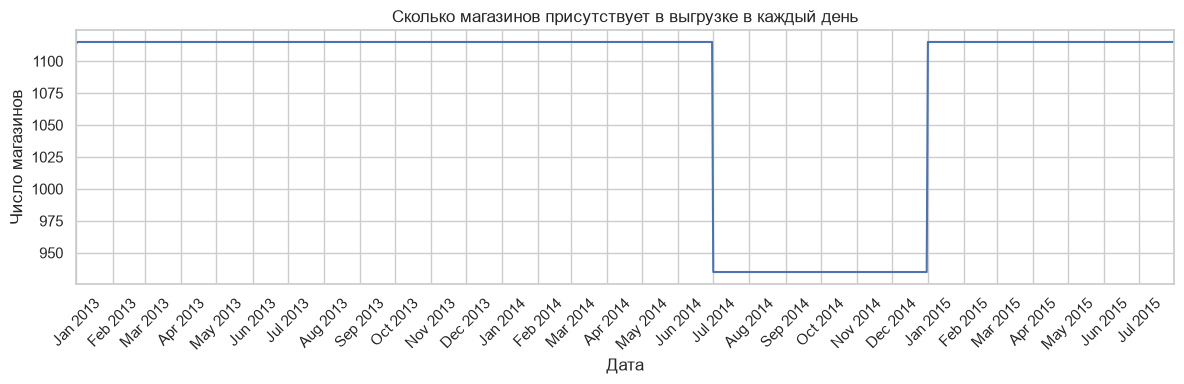

In [5]:
stores_per_day = train.groupby("Date")["Store"].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
stores_per_day.plot(ax=ax)
ax.set(title="Сколько магазинов присутствует в выгрузке в каждый день")
ax.set(xlabel="Дата")
ax.set(ylabel="Число магазинов")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
rows_per_store.value_counts().rename_axis("дней с данными").to_frame("магазинов")

,магазинов
дней с данными,
942,934
758,180
941,1


In [7]:
n_stores = train["Store"].nunique()

summary = pd.Series({
    "Дней со всеми магазинами": (stores_per_day == n_stores).sum(),
    "Дней с неполной выгрузкой": (stores_per_day < n_stores).sum(),
    "Минимум магазинов за день": stores_per_day.min(),
    "Отсутствующих пар 'магазин x дата'": n_stores * len(full_range) - len(train),
}).to_frame("Количество")

summary

,Количество
Дней со всеми магазинами,757
Дней с неполной выгрузкой,185
Минимум магазинов за день,935
Отсутствующих пар 'магазин x дата',33121


Весь период (942 дня) в выборке присутствует только 934 магазина из 1115. Весь период, кроме одного дня, присутствует только у 1 магазина. Провал на графике наблюдается с июля по декабрь 2014 (185 дней) - у 180 магазинов нет строк за этот период. Предполагается, что это не период, когда магазин закрыт (так как закрытые дни обозначаются признаком `Open = 0`), а пропуск в выгрузке. То есть в данных 185 дней с неполной выгрузкой и 33121 отсутствующая пара "магазин x дата" При восстановлении календаря в строках с такими пропусками в признаке `Customers` будет стоять `NaN`, также будет добавлен дополнительный признак, сигнализирующий о проблемах с выгрузкой (`Missing_export`). 

Ошибки в выгрузке не затрагивают последние недели (июнь-июль 2015), из которых сформируется тестовая выборка.
 
**Note!** Дни с ошибкой в выгрузке не участвуют ни в обучении, ни в метриках, и лаги через них не протягиваются, потому что подставить 0 значило бы выдать сбой выгрузки за закрытие магазина.

## 2. Дизайн разбиения на тренировочную и тестовую выборки

Чтобы не было утечки данных, сразу зафиксируем тестовую выборку.

В качестве отложенной выборки взяты последние 6 недель (42 дня), то есть каждый день недели встречается в тесте ровно 6 раз, метрика не перекошена по дням недели.

Начало тестовой выборки обозначает `TEST_START` (первый день). В тест попадают все значения, которые `>= TEST_START`, в тренировочную выборку - все, что `<= TRAIN_END`.

In [8]:
TEST_WEEKS = 6
TEST_START = full_range[-1] - pd.Timedelta(weeks=TEST_WEEKS) + pd.Timedelta(days=1)
TRAIN_END = TEST_START - pd.Timedelta(days=1)
test_days = pd.date_range(TEST_START, full_range[-1], freq="D")

print(f"Train: {full_range[0].date()} - {TRAIN_END.date()} ({(TRAIN_END - full_range[0]).days + 1} дней)")
print(f"Test:  {TEST_START.date()} - {full_range[-1].date()} ({len(test_days)} дней)")

test_rows = train[train["Date"] >= TEST_START]
print(f"Государственные праздники в тесте: {test_rows['StateHoliday'].value_counts().to_dict()}")
print(f"Доля строк со школьными каникулами в тесте: {test_rows['SchoolHoliday'].mean():.2f}")

Train: 2013-01-01 - 2015-06-19 (900 дней)
Test:  2015-06-20 - 2015-07-31 (42 дней)
Государственные праздники в тесте: {'0': 46830, 'a': 0, 'b': 0, 'c': 0}
Доля строк со школьными каникулами в тесте: 0.29


В тренировочной выборке ровно 900 дней (с 01.01.2013 по 19.06.2015), в тестовой выборке 42 дня (с 20.06.2015 по 31.07.2015).

В тестовую выборку не попал ни один государственный праздник, однако 29% строк приходятся на школьные каникулы. Следовательно, отложенный период не проверяет, как модель справляется с праздниками. Устойчивость модели к праздничным периодам необходимо дополнительно оценить на исторических данных путем скользящей валидации внутри тренировочной выборки без перемешивания наблюдений.

## 3. Исследование датасета с метаинформацией `store.csv`

In [9]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [10]:
store_missing = (store.isna()
                 .agg(["sum", "mean"]).T
                 .rename(columns={"sum": "пропусков", "mean": "доля"}))
store_missing[store_missing["пропусков"] > 0].round(3)

,пропусков,доля
CompetitionDistance,3.0,0.003
CompetitionOpenSinceMonth,354.0,0.317
CompetitionOpenSinceYear,354.0,0.317
Promo2SinceWeek,544.0,0.488
Promo2SinceYear,544.0,0.488
PromoInterval,544.0,0.488


Датасет `store.csv` представляет собой метаинформацию для 1115 магазинов, где каждая строка посвящена уникальному магазину, в нем 10 признаков.

Идентификаторы магазинов, их тип, ассортимент и признак участия в Promo2 заполнены полностью. Пропуски сосредоточены только в характеристиках конкуренции и Promo2.

Информация о дистанции до конкурента отсутствует только для трех магазинов, то есть эти пропуски являются единичными. Гораздо чаще отсутствуют данные о дате открытия конкурента (для 354 магазинов не указаны месяц и год), для признаков, связанных с промоакциями/рекламой (Promo2), пропуски наблюдаются почти у половины магазинов.

Можно выдвинуть следующие гипотезы:
* пропуски в `Promo2SinceWeek`, `Promo2SinceYear` и `PromoInterval` структурные, так как эти поля неприменимы к магазинам, которые не участвуют в промоакции/рекламе (`Promo2` == 0);
* дата открытия конкурента пропущена тогда, когда дата неизвестна (то есть пустые поля в `CompetitionOpenSinceMonth` и `CompetitionOpenSinceYear` находятся у одинаковых объектов);
* пропуск в дистанции до конкурента (`CompetitionDistance`) означает, что конкурента нет, следовательно, у таких магазинов не должно быть и даты открытия конкурента.

### 3.1 Природа пропусков

In [11]:
promo2_cols = ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
competition_cols = ["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"]

promo2_missing = store[promo2_cols].isna()
competition_missing = store[competition_cols].isna()

pd.Series({
    "Promo2 == 0 => все три поля Promo* пустые (и наоборот)":
        promo2_missing.all(axis=1).eq(store["Promo2"].eq(0)).all(),
    "Магазинов, где Promo2-поля пусты лишь частично":
        (promo2_missing.any(axis=1) & ~promo2_missing.all(axis=1)).sum(),
    "Месяц и год открытия конкурента пусты одновременно":
        competition_missing.any(axis=1).eq(competition_missing.all(axis=1)).all(),
    "Нет расстояния до конкурента, но есть дата открытия":
        (store["CompetitionDistance"].isna() & store["CompetitionOpenSinceYear"].notna()).sum(),
    "Есть расстояние до конкурента, но нет даты открытия":
        (store["CompetitionDistance"].notna() & store["CompetitionOpenSinceYear"].isna()).sum(),
}).to_frame("результат")

,результат
Promo2 == 0 => все три поля Promo* пустые (и наоборот),True
"Магазинов, где Promo2-поля пусты лишь частично",0
Месяц и год открытия конкурента пусты одновременно,True
"Нет расстояния до конкурента, но есть дата открытия",0
"Есть расстояние до конкурента, но нет даты открытия",351


Все три гипотезы из предыдущего раздела подтвердились:
- `Promo2SinceWeek`, `Promo2SinceYear` и `PromoInterval` пусты ровно у 544 магазинов с `Promo2 == 0` и ни у одного - частично. Пропуски действительно структурные: заполнять NaN не нужно.
- Месяц и год открытия конкурента всегда пропущены вместе (354 магазина, 32%). У 351 из них расстояние до конкурента известно: конкурент есть, но дата его появления неизвестна. Поэтому флаг "конкурент открылся внутри тренировочного набора" у этих магазинов будет равен `False` не потому, что открытия не было, а потому, что мы о нем не знаем.
- У 3 магазинов нет ни расстояния, ни даты. Такая комбинация будет трактоваться как "конкурента нет": при построении признаков будет отдельный флаг, а не заполнение медианой.

### 3.2 Тип магазина и ассортимент

In [12]:
type_assortment = pd.crosstab(store["StoreType"], store["Assortment"])
pd.crosstab(store["StoreType"], store["Assortment"], margins=True, margins_name="всего")

Assortment,a,b,c,всего
StoreType,,,,
a,381,0,221,602
b,7,9,1,17
c,77,0,71,148
d,128,0,220,348
всего,593,9,513,1115


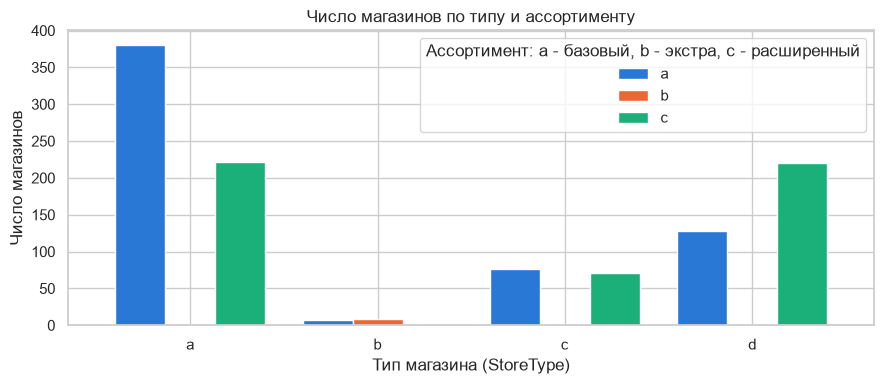

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
type_assortment.plot.bar(ax=ax, color=["#2a78d6", "#eb6834", "#1baf7a"], width=0.8, rot=0)
ax.set(title="Число магазинов по типу и ассортименту")
ax.set(xlabel="Тип магазина (StoreType)")
ax.set(ylabel="Число магазинов")
ax.legend(title="Ассортимент: a - базовый, b - экстра, c - расширенный")
plt.tight_layout()
plt.show()

Тип магазина `a` самый массовый (602 магазина), тип `b` самый редкий (всего 17 магазинов). При этом ассортимент типа `b` (экстра) встречается только у типа магазина `b` (9 из 17 магазинов).

Для магазина типа `a` характернее базовый ассортимент (хотя расширенный также представлен), а для магазина типа `d`, наоборот, скорее характерен расширенный ассортимент.

То есть тип магазина и ассортимент частично дублируют друго друга.

Так как стоит задача создать репрезентативную сбалансированную выборку, необходимо учитывать малочисленность типа магазина `b`.

### 3.3 Расстояние до конкурента

In [14]:
store["CompetitionDistance"].describe().round(0)

count     1112.0
mean      5405.0
std       7663.0
min         20.0
25%        718.0
50%       2325.0
75%       6882.0
max      75860.0
Name: CompetitionDistance, dtype: float64

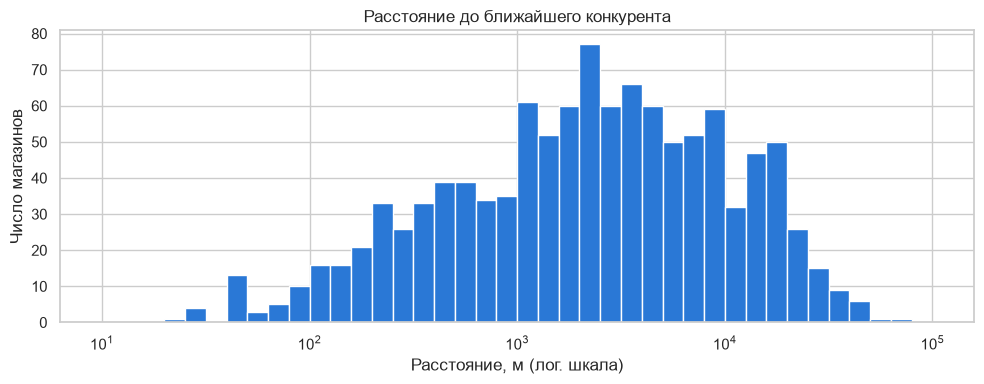

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(store["CompetitionDistance"].dropna(), bins=np.logspace(1, 5, 41),
        color="#2a78d6", edgecolor="white")
ax.set_xscale("log")
ax.set(title="Расстояние до ближайшего конкурента",
       xlabel="Расстояние, м (лог. шкала)", ylabel="Число магазинов")
plt.tight_layout()
plt.show()

Распределение расстояния до конкурента сильно скошено вправо: среднее более чем в 2 раза выше медианы (5.4 км vs 2.3 км), 75-й перцентиль равен 6.9 км, максимум - 76 км. Логарифмирование шкалы помогает привести распределение к симметричному. Из-за скошенности распределения сырые значения в дальнейшем анализе использоваться не будут, будут использоваться логарифм расстояния или квартили.

### 3.4 Когда открылся конкурент

В данных есть только год и месяц открытия, поэтому датой открытия будет 1-е число месяца. Характеристики, вычисленные на основе `store.csv`, хранятся в отдельной таблице `store_extra`, а исходный `store` не меняется.

In [16]:
competition_open = pd.to_datetime(
    store[competition_cols]
    .rename(columns={"CompetitionOpenSinceYear": "year", "CompetitionOpenSinceMonth": "month"})
    .assign(day=1),
    errors="coerce",
)
store_extra = pd.DataFrame({"competition_open": competition_open.to_numpy()}, index=store["Store"])

opened_by_year = competition_open.dt.year.value_counts().sort_index()
years_in_data = opened_by_year.index.isin(range(full_range[0].year, full_range[-1].year + 1))

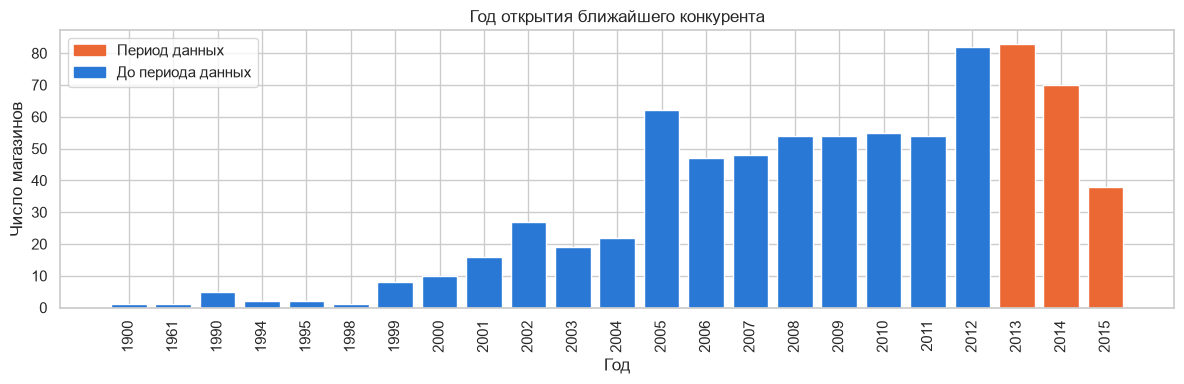

Самые ранние годы: {1900.0: 1, 1961.0: 1, 1990.0: 5, 1994.0: 2, 1995.0: 2, 1998.0: 1, 1999.0: 8, 2000.0: 10, 2001.0: 16, 2002.0: 27}


In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(opened_by_year.index.astype(int).astype(str), opened_by_year.values,
       color=np.where(years_in_data, "#eb6834", "#2a78d6"))
ax.set(title="Год открытия ближайшего конкурента",
       xlabel="Год", ylabel="Число магазинов")
legend_handles = [
    Patch(color="#eb6834", label="Период данных"),
    Patch(color="#2a78d6", label="До периода данных"),
]
ax.legend(handles=legend_handles, loc="upper left")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Самые ранние годы: {opened_by_year.head(10).to_dict()}")

Большинство конкурентов открылись в 2005–2014 годах. Пиковым является 2013 год, немного меньше открытий приходится на 2012 и 2014. Есть подозрительные значения: 1900 и 1961 год (открылось по одному магазину). 1900 похож скорее на заглушку, а не на реальную дату.

На отбор данных это не влияет: такие открытия раньше начала данных.

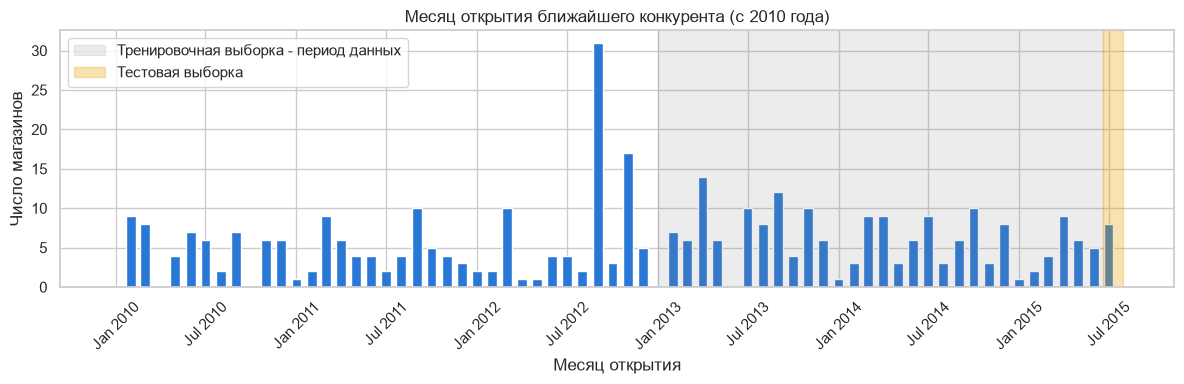

In [18]:
months = pd.period_range("2010-01", full_range[-1].to_period("M"), freq="M")
opened_by_month = (competition_open.dt.to_period("M")
                   .value_counts()
                   .reindex(months, fill_value=0))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(opened_by_month.index.to_timestamp(), opened_by_month.values, width=20, color="#2a78d6")
ax.axvspan(full_range[0], TRAIN_END, color="grey", alpha=0.15, label="Тренировочная выборка - период данных")
ax.axvspan(TEST_START, full_range[-1], color="#eda100", alpha=0.3, label="Тестовая выборка")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title="Месяц открытия ближайшего конкурента (с 2010 года)",
       xlabel="Месяц открытия", ylabel="Число магазинов")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
store_extra["competitor_opened_in_train"] = (
    store_extra["competition_open"].gt(full_range[0]) & store_extra["competition_open"].le(TRAIN_END)
)
pd.Series({
    "Дата открытия неизвестна": store_extra["competition_open"].isna().sum(),
    "Открылся до начала данных": store_extra["competition_open"].le(full_range[0]).sum(),
    "Открылся внутри периода тренировочной выборки": store_extra["competitor_opened_in_train"].sum(),
    "Открылся внутри периода тестовой выборки": store_extra["competition_open"].gt(TRAIN_END).sum(),
}).to_frame("магазинов")

,магазинов
Дата открытия неизвестна,354
Открылся до начала данных,570
Открылся внутри периода тренировочной выборки,180
Открылся внутри периода тестовой выборки,11


Внутри периода данных конкуренты открываются равномерно, без массовых всплесков (заметный всплеск в сентябре 2012 года, но он до начала данных).

Открытие ближайшего конкурента внутри тренировочного периода рассматривается как потенциальный структурный сдвиг во временном ряду - после даты открытия условия конкуренции для магазина меняются. Такие случаи будут отдельно представлены в EDA на выборке и проверены на наличие изменений уровня и динамики спроса.

В методике подсчета присутствует ограничение: предполагается, что открытие произошло 1 числа месяца, поэтому открытия июня 2015 отнесены к тренировочной выборке, хотя часть этих открытий могла произойти после 19.06.

### 3.5 Реклама

Для отбора достаточно знать, участвует ли магазин в промоакции/рекламе (`Promo2` = 0/1); природа пропусков в `Promo2SinceWeek`, `Promo2SinceYear` была проверена в блоке 3.1. Более подробно информация о промоакциях/рекламе будет исследоваться на выборке.

In [20]:
display(store["Promo2"].value_counts().rename("магазинов").to_frame())
store["PromoInterval"].value_counts(dropna=False).rename("магазинов").to_frame()

,магазинов
Promo2,
1,571
0,544


,магазинов
PromoInterval,
NaN,544
"Jan,Apr,Jul,Oct",335
"Feb,May,Aug,Nov",130
"Mar,Jun,Sept,Dec",106


Магазины почти поровну разделены по участию в промоакциях/рекламе - 571 магазин участвует в промоакциях/рекламе, 544 магазина не участвует. Среди участвующих магазинов наиболее распространен интервал `январь, апрель, июль, октябрь` (335 магазинов).

## 4. Закрытия магазинов и пропуски выгрузки

Дни, когда магазин закрыт (`Open = 0`), бывают двух видов: **регулярные закрытия** (воскресенье, праздник - известно по расписанию) и **длинные закрытия** (ремонт или период, когда точки нет). 

В этом блоке будут анализироваться последовательные серии дней, когда магазин закрыт. Серия прерывается, если статус `Open` меняется на `1` или если в данных есть разрыв по датам. Такой подход не позволяет ошибочно объединить закрытия, между которыми отсутствуют наблюдения. 

In [21]:
store_daily = (train.sort_values(["Store", "Date"])
           .assign(is_state_holiday=lambda d: d["StateHoliday"].ne("0")))
is_closed = store_daily["Open"].eq(0)

new_run = (
    is_closed.ne(is_closed.groupby(store_daily["Store"]).shift())
    | store_daily["Date"].diff().ne(pd.Timedelta(days=1))
)
run_id = new_run.cumsum()

closure_runs = (store_daily[is_closed]
                .groupby(run_id[is_closed])
                .agg(store=("Store", "first"), start=("Date", "min"), end=("Date", "max"),
                     days=("Date", "size"), has_holiday=("is_state_holiday", "any"))
                .reset_index(drop=True))

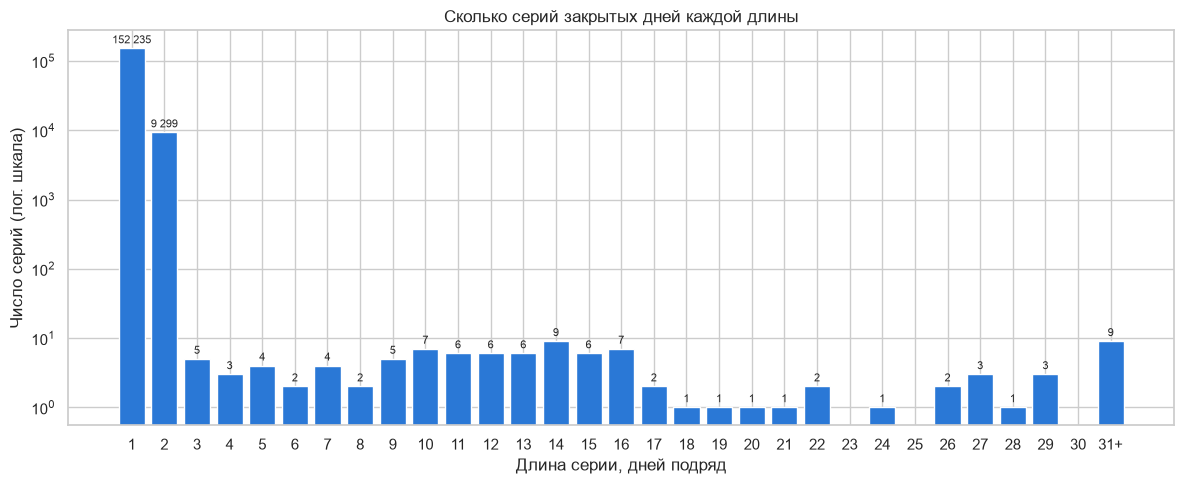

In [22]:
MAX_LEN_SHOWN = 30
run_length_counts = (closure_runs["days"]
                     .clip(upper=MAX_LEN_SHOWN + 1)
                     .value_counts()
                     .sort_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(run_length_counts.index, run_length_counts.values, width=0.8, color="#2a78d6")
ax.set_yscale("log")
for length, n in run_length_counts.items():
    ax.annotate(f"{n:,}".replace(",", " "), (length, n), xytext=(0, 2),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)

x_ticks = range(1, MAX_LEN_SHOWN + 2)
ax.set_xticks(x_ticks, [str(t) for t in x_ticks[:-1]] + [f"{MAX_LEN_SHOWN + 1}+"])
ax.set(title="Сколько серий закрытых дней каждой длины",
       xlabel="Длина серии, дней подряд", ylabel="Число серий (лог. шкала)")

plt.tight_layout()
plt.show()

Больше всего серий закрытий, равных 1 и 2 дням, то есть это праздники и выходные. Закрытий, которые длятся больше месяца всего 9.

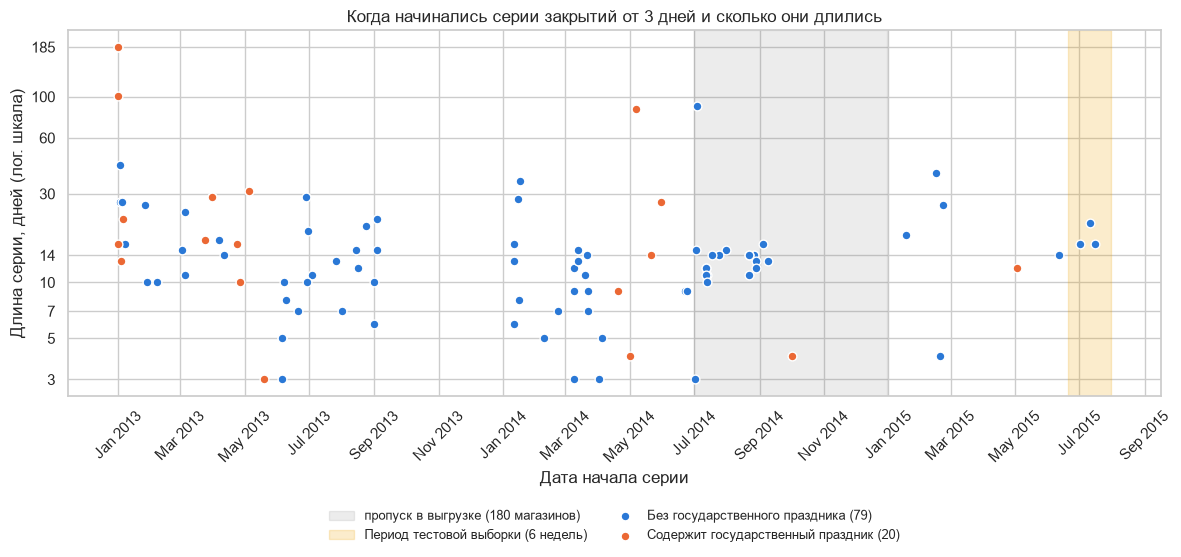

In [23]:
MIN_LEN_SHOWN = 3
EXPORT_GAP = (pd.Timestamp("2014-07-01"), pd.Timestamp("2014-12-31"))

runs_view = closure_runs[closure_runs["days"] >= MIN_LEN_SHOWN]

fig, ax = plt.subplots(figsize=(12, 6))
ax.axvspan(*EXPORT_GAP, color="grey", alpha=0.15, label="пропуск в выгрузке (180 магазинов)")
ax.axvspan(TEST_START, full_range[-1], color="#eda100", alpha=0.2,
           label=f"Период тестовой выборки ({TEST_WEEKS} недель)")
for flag, color, label in [(False, "#2a78d6", "Без государственного праздника"),
                           (True, "#eb6834", "Содержит государственный праздник")]:
    part = runs_view[runs_view["has_holiday"] == flag]
    ax.scatter(part["start"], part["days"], s=40, color=color, edgecolor="white", linewidth=1,
               label=f"{label} ({len(part)})")

y_ticks = [3, 5, 7, 10, 14, 30, 60, 100, 185]
ax.set_yscale("log")
ax.set_yticks(y_ticks, [str(t) for t in y_ticks])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title=f"Когда начинались серии закрытий от {MIN_LEN_SHOWN} дней и сколько они длились",
       xlabel="Дата начала серии", ylabel="Длина серии, дней (лог. шкала)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, fontsize=9, frameon=False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Праздник очень редко является причиной закрытия: 79 серий закрытий из 99 не содержат государственного праздника. Оранжевые точки в основном попадают в длинные серии закрытий, в которые праздник попал просто из-за длительности периода (например, периоды с Пасхой). Коротких серий, включающих праздник всего 3.

Основная масса закрытий лежит в диапазоне 7-30 дней. Очень длинные закрытия (60-185 дней) единичны. 

В левой части графика сосредоточены серии, начавшиеся в первый день данных, однако реальное начало закрытия неизвестно.

Исходя из вышеперечисленного, серии закрытий от 3 дней - это индивидуальные события отдельных магазинов (например, ремонты): они разбросаны по всему периоду, не совпадают с праздниками и почти не встречаются в сезон повышенного спроса (октябрь-декабрь). Значит, такие периоды нельзя предсказать по календарю - такие периоды стоит трактовать как "точки нет", а не как регулярный выходной.

В период тестовой выборки попадают 4 серии, одна из серий начинается до теста. Такие магазины исключаются из отбора.

Исходя из двух графиков, в качестве порога длинного закрытия выбран `3` (серии закрытий в 1 и 2 дня массовые, на длине 3 число серий резко уменьшается + серии от 3х дней разбросаны по календарю у разных магазинов и большинство из них не содержит государственного праздника. Значит, это индивидуальные закрытия).

In [24]:
N_LONG = 3

closure_runs["is_long"] = closure_runs["days"] >= N_LONG
closure_runs["is_left_censored"] = closure_runs["start"].eq(full_range[0])
closure_runs["in_test"] = closure_runs["end"].ge(TEST_START)
closure_runs["not_finished"] = closure_runs["end"].eq(full_range[-1])
long_runs = closure_runs[closure_runs["is_long"]]

Проверка выбранного порога:

In [25]:
(long_runs[long_runs["days"] < 7]
 .assign(start_day=lambda d: d["start"].dt.day_name(), end_day=lambda d: d["end"].dt.day_name())
 .sort_values(["has_holiday", "start"])
 [["store", "start", "start_day", "end", "end_day", "days", "has_holiday"]])

,store,start,start_day,end,end_day,days,has_holiday
64277,444,2013-06-05,Wednesday,2013-06-07,Friday,3,False
92183,638,2013-06-05,Wednesday,2013-06-09,Sunday,5,False
103197,715,2013-06-05,Wednesday,2013-06-09,Sunday,5,False
139507,964,2013-09-01,Sunday,2013-09-06,Friday,6,False
142379,983,2014-01-11,Saturday,2014-01-16,Thursday,6,False
56530,390,2014-02-09,Sunday,2014-02-13,Thursday,5,False
47360,327,2014-03-09,Sunday,2014-03-11,Tuesday,3,False
2938,20,2014-04-02,Wednesday,2014-04-04,Friday,3,False
133438,922,2014-04-05,Saturday,2014-04-09,Wednesday,5,False
8410,57,2014-07-02,Wednesday,2014-07-04,Friday,3,False


Серий закрытий длиной 3-6 дней всего 14:
* только 3 серии содержат государственный праздник. Две серии похожи на связку "праздник + выходной": магазин 1100 закрыт 1–4 мая 2014 года, магазин 708 - 2–5 октября 2014 года (с четверга по воскресенье);
* остальные 11 серий без праздников. Три магазина (444, 638, 715) закрылись одновременно 5 июня 2013 года: похоже на общее событие в одном регионе.

Ни одна из этих серий закрытий не повторяется по всей сети, то есть по календарю ее не предсказать, поэтому трактовать их как "точки нет", а не как регулярный выходной, корректно. Порог также корректен.

### 4.1 Сколько магазинов закрывались надолго

In [26]:
n_long_per_store = long_runs.groupby("store").size().reindex(store["Store"], fill_value=0)

closure_count = (n_long_per_store.clip(upper=2)
                 .map({0: "0", 1: "1", 2: "2+"})
                 .value_counts()
                 .reindex(["0", "1", "2+"], fill_value=0)
                 .rename_axis("долгих закрытий")
                 .to_frame("магазинов"))
closure_count["доля"] = (closure_count["магазинов"] / len(store)).round(3)

print(f"Долгих закрытий всего: {len(long_runs)}")
print(f"Уникальных магазинов хотя бы с одним долгим закрытием: {(n_long_per_store > 0).sum()}")
closure_count

Долгих закрытий всего: 99
Уникальных магазинов хотя бы с одним долгим закрытием: 93


,магазинов,доля
долгих закрытий,,
0,1022,0.917
1,88,0.079
2+,5,0.004


In [27]:
(store.set_index("Store")["StoreType"].to_frame()
 .assign(has_long=n_long_per_store > 0)
 .groupby("StoreType")["has_long"]
 .agg(магазинов="size", с_длинным_закрытием="sum", доля="mean")
 .round(3))

,магазинов,с_длинным_закрытием,доля
StoreType,,,
a,602,55,0.091
b,17,7,0.412
c,148,17,0.115
d,348,14,0.040


Всего долгих закрытий в датасете 99. У 93 уникальных магазинов есть хотя бы одно закрытие. У 5 магазинов серий закрытий 2 и больше. 

Доля магазинов с хотя бы одним долгим закрытием различается между типами магазинов. Наиболее высокая доля наблюдается у типа `b` - 41,2% (7 из 17 магазинов), однако этот тип представлен всего 17 магазинами, поэтому оценка для него менее стабильна. Для типов `a`, `c` и `d` доля составляет 9,1%, 11,5% и 4,0% соответственно. Полученное различие следует учитывать при формировании выборки, но не интерпретировать как причинную зависимость.

### 4.2 Закрытия на границах данных

In [28]:
print("Долгие закрытия, начавшиеся в первый день данных:")
display(long_runs[long_runs["is_left_censored"]])

print("Долгие закрытия, пересекающие период тестовой выборки:")
long_runs[long_runs["in_test"]]

Долгие закрытия, начавшиеся в первый день данных:


,store,start,end,days,has_holiday,is_long,is_left_censored,in_test,not_finished
15032,103,2013-01-01,2013-07-04,185,True,True,True,False,False
50427,349,2013-01-01,2013-04-11,101,True,True,True,False,False
109963,762,2013-01-01,2013-01-16,16,True,True,True,False,False
156853,1081,2013-01-01,2013-07-04,185,True,True,True,False,False


Долгие закрытия, пересекающие период тестовой выборки:


,store,start,end,days,has_holiday,is_long,is_left_censored,in_test,not_finished
26748,183,2015-06-12,2015-06-25,14,False,True,False,True,False
42376,292,2015-07-11,2015-07-31,21,False,True,False,True,True
126801,876,2015-07-16,2015-07-31,16,False,True,False,True,True
131603,909,2015-07-02,2015-07-17,16,False,True,False,True,False


В начале данных долгие закрытия есть у 4 магазинов: 103 и 1081 (у обоих по 185 дней, до 4 июля 2013 года), 349 (101 день), 762 (16 дней). Из-за невозможности установить истинную причину закрытия будем считать, что такой магазин появился в данных позже, такие магазины в выборке остаются, а период до открытия получает статус "точки нет".

В период тестовой выборки закрыты 4 магазина: 183, 292, 876, 909. У двух из них (292 и 876) закрытие не закончилось к концу данных. Эти магазины исключаются из отбора, так как прогнозировать закрытый магазин бессмысленно.

### 4.3 Отсутствующие строки: сбой выгрузки или закрытие?

В разделе 1 было выдвинуто предположение, что отсутствующие строки это пропуск в выгрузке. Необходимо это проверить - найти все разрывы в датах по каждому магазину и посмотреть, как ведут себя магазины на границах разрыва. Если магазины с пропуском работали до и после него так же, как магазины без пропуска, то это сбой выгрузки, а не закрытие.

In [29]:
first_date = store_daily.groupby("Store")["Date"].min()
last_date = store_daily.groupby("Store")["Date"].max()

inner_gaps = (store_daily.assign(prev_date=store_daily.groupby("Store")["Date"].shift())
              .loc[lambda d: d["Date"] - d["prev_date"] > pd.Timedelta(days=1)]
              .assign(gap_start=lambda d: d["prev_date"] + pd.Timedelta(days=1),
                      gap_end=lambda d: d["Date"] - pd.Timedelta(days=1))
              [["Store", "gap_start", "gap_end"]])
leading_gaps = (first_date[first_date > full_range[0]].rename("gap_end").reset_index()
                .assign(gap_start=full_range[0], gap_end=lambda d: d["gap_end"] - pd.Timedelta(days=1)))
trailing_gaps = (last_date[last_date < full_range[-1]].rename("gap_start").reset_index()
                 .assign(gap_start=lambda d: d["gap_start"] + pd.Timedelta(days=1), gap_end=full_range[-1]))

export_gaps = (pd.concat([inner_gaps, leading_gaps, trailing_gaps], ignore_index=True)
               .assign(days=lambda d: (d["gap_end"] - d["gap_start"]).dt.days + 1))

print(f"Отсутствующих пар 'магазин х дата': {export_gaps['days'].sum()} "
      f"(ожидаем {train['Store'].nunique() * len(full_range) - len(train)})")
export_gaps.groupby(["gap_start", "gap_end", "days"]).size().rename("магазинов").to_frame()

Отсутствующих пар 'магазин х дата': 33121 (ожидаем 33121)


,,,магазинов
gap_start,gap_end,days,
2013-01-01,2013-01-01,1,1
2014-07-01,2014-12-31,184,180


In [30]:
main_gap = export_gaps.loc[export_gaps["days"].idxmax()]
gap_stores = export_gaps.loc[export_gaps["days"] > 1, "Store"].unique()
border_days = pd.date_range(main_gap["gap_start"] - pd.Timedelta(days=3), periods=3).append(
    pd.date_range(main_gap["gap_end"] + pd.Timedelta(days=1), periods=3))

(train[train["Date"].isin(border_days)]
 .assign(group=lambda d: np.where(d["Store"].isin(gap_stores), "с дырой", "без дыры"))
 .pivot_table(index="Date", columns="group", values="Open", aggfunc="mean")
 .assign(день_недели=lambda d: d.index.day_name())
 .round(3))

group,без дыры,с дырой,день_недели
Date,,,
2014-06-28,0.997,1.000,Saturday
2014-06-29,0.033,0.006,Sunday
2014-06-30,0.997,1.000,Monday
2015-01-01,0.018,0.006,Thursday
2015-01-02,1.000,1.000,Friday
2015-01-03,1.000,1.000,Saturday


Все разрывы в датах сводятся к двум случаям: у 180 магазинов нет периода с 01.07.2014 по 31.12.2014 (184 дня), у одного магазина нет 01.01.2013. Всего в данных отсутствует 33121 пара "магазин х дата", что совпадает с подсчетом из раздела 1.

На границах пропусков магазины с пропуском ведут себя так же, как магазины без пропуска: перед пропуском в субботу и понедельник большинство магазинов открыто, а в воскресенье закрыто, также 1 января 2015 года закрыты почти все магазины, а 2 января магазины снова открыты.

Если бы пропуск был ремонтом, то магазины были бы закрыты и вокруг этого пропуска. Поэтому пропуски - это сбой выгрузки, а не закрытие магазина.

## 5. Профиль магазинов

В этом разделе объединяются датасеты `train` и `store` на уровне магазина: из `train` считаем агрегированные данные по каждому магазину и присоединяем к ним характеристики из `store`. Это необходимо, чтобы понять, какие магазины представлены в датасете, найти типичные и проблемные случаи и, основываясь на этой информации, сформировать выборку.

Учитывается следующее:
- **поведенческие характеристики** (медиана гостей, средний чек, коэффициент вариации, рост год к году) считаются только по трейну (`<= TRAIN_END`) и только по открытым дням с ненулевым числом гостей;
- **расписание** (сколько дней магазин открыт в тесте) можно брать из теста: оно известно заранее.

**Рост год к году** - средний поток на открытый день за 01.01–19.06.2015 против тех же дат 2014 года. Окно выбрано так, чтобы оно было у всех магазинов (не пересекалось с ошибкой выгрузки), не заходило в тест и содержало все весенние праздники в оба года (Пасха, Вознесение, Троица), которые празднуются в разное время.

In [31]:
train_part = train[train["Date"] <= TRAIN_END]
open_train = train_part[train_part["Open"].eq(1) & train_part["Customers"].gt(0)]

growth_windows = {
    "2014": (pd.Timestamp("2014-01-01"), TRAIN_END - pd.DateOffset(years=1)),
    "2015": (pd.Timestamp("2015-01-01"), TRAIN_END),
}
window_stats = {
    year: open_train[open_train["Date"].between(start, end)]
          .groupby("Store")["Customers"].agg(["mean", "size"])
    for year, (start, end) in growth_windows.items()
}

closed_days = train["Open"].eq(0).groupby(train["Store"]).sum()
long_closure_days = long_runs.groupby("store")["days"].sum().reindex(store["Store"], fill_value=0)
check = open_train.groupby("Store")[["Sales", "Customers"]].sum()

profile = (
    store.set_index("Store")[["StoreType", "Assortment", "CompetitionDistance", "Promo2"]]
    .join(store_extra["competitor_opened_in_train"])
    # пропуски и закрытия
    .join((len(full_range) - rows_per_store).rename("missing_days"))
    .join(n_long_per_store.rename("n_long_closures"))
    .join(long_closure_days.rename("long_closure_days"))
    .join(((closed_days - long_closure_days) / rows_per_store).rename("share_regular_closed"))
    .join((long_closure_days / rows_per_store).rename("share_long_closed"))
    .join(train_part[train_part["Open"].eq(1) & train_part["Customers"].eq(0)]
          .groupby("Store").size().rename("n_anomalies"))
    # расписание
    .join(train[train["Open"].eq(1) & train["Date"].dt.dayofweek.eq(6)]
          .groupby("Store").size().rename("sunday_open_days"))
    .join(train[train["Date"] >= TEST_START].groupby("Store")["Open"].sum().rename("open_days_test"))
    # поведение целевой (только на трейне)
    .join(open_train.groupby("Store")["Customers"]
          .agg(guests_median="median", guests_cv=lambda s: s.std() / s.mean()))
    .join((check["Sales"] / check["Customers"]).rename("avg_check"))
    .join(window_stats["2014"]["size"].rename("open_days_2014"))
    .join(window_stats["2015"]["size"].rename("open_days_2015"))
    .join((window_stats["2015"]["mean"] / window_stats["2014"]["mean"] - 1).rename("growth_raw"))
)

count_cols = ["n_anomalies", "sunday_open_days", "open_days_2014", "open_days_2015"]
profile[count_cols] = profile[count_cols].fillna(0).astype(int)
profile = profile.assign(
    has_export_gap=profile["missing_days"] > 1,
    has_long_closure=profile["n_long_closures"] > 0,
    has_left_censored=profile.index.isin(long_runs.loc[long_runs["is_left_censored"], "store"]),
    closed_in_test=profile.index.isin(long_runs.loc[long_runs["in_test"], "store"]),
    sunday_open=profile["sunday_open_days"] > 0,
)
print(profile.shape)
profile.head()

(1115, 24)


,StoreType,Assortment,CompetitionDistance,Promo2,competitor_opened_in_train,missing_days,n_long_closures,long_closure_days,share_regular_closed,share_long_closed,n_anomalies,sunday_open_days,open_days_test,guests_median,guests_cv,avg_check,open_days_2014,open_days_2015,growth_raw,has_export_gap,has_long_closure,has_left_censored,closed_in_test,sunday_open
Store,,,,,,,,,,,,,,,,,,,,,,,,
1,c,a,1270.0,0,False,0,0,0,0.170913,0.0,0,0,36,554.0,0.166781,8.428430,139,139,-0.037848,False,False,False,False,False
2,a,a,570.0,1,False,0,0,0,0.167728,0.0,0,0,36,577.0,0.263209,8.495676,140,140,-0.009992,False,False,False,False,False
3,a,a,14130.0,1,False,0,0,0,0.173036,0.0,0,0,36,750.0,0.227281,9.226733,139,139,-0.009927,False,False,False,False,False
4,c,c,620.0,0,False,0,0,0,0.167728,0.0,0,0,36,1302.5,0.151454,7.267183,140,140,0.006029,False,False,False,False,False
5,a,a,29910.0,0,True,0,0,0,0.173036,0.0,0,0,36,568.0,0.308679,8.697298,140,140,0.003719,False,False,False,False,False


In [32]:
profile.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
CompetitionDistance,1112.0,5404.901,7663.175,20.000,717.500,2325.000,6882.500,75860.000
Promo2,1115.0,0.512,0.500,0.000,0.000,1.000,1.000,1.000
missing_days,1115.0,29.705,67.729,0.000,0.000,0.000,0.000,184.000
n_long_closures,1115.0,0.089,0.306,0.000,0.000,0.000,0.000,3.000
long_closure_days,1115.0,1.779,10.447,0.000,0.000,0.000,0.000,185.000
share_regular_closed,1115.0,0.168,0.025,0.000,0.169,0.172,0.173,0.183
share_long_closed,1115.0,0.002,0.011,0.000,0.000,0.000,0.000,0.196
n_anomalies,1115.0,0.047,0.260,0.000,0.000,0.000,0.000,3.000
sunday_open_days,1115.0,3.222,19.012,0.000,0.000,0.000,0.000,134.000
open_days_test,1115.0,36.127,1.298,18.000,36.000,36.000,36.000,42.000


Получился профиль 1115 магазинов (24 характеристики).

В сводной статистике наблюдается следующее:

**1. Проблемные случаи редкие - большинство магазинов обычные** (По `missing_days`, `n_long_closures`, `n_anomalies` и `sunday_open_days` даже 75-й перцентиль равен 0):
- дыра в выгрузке есть меньше чем у четверти магазинов;
- длинные закрытия - в среднем 0.09 на магазин (максимум 3);
- аномалий "открыт, но 0 гостей" всего 0.05 на магазин, то есть около 50 дней на всю сеть.

Из-за редкости проблемных случаев случайная выборка из 40 магазинов легко может не содержать ни одного такого проблемного случая, поэтому проблемные группы будут включаться в отбор принудительно.

**2. Расписание у сети почти одинаковое.** `share_regular_closed` у половины магазинов в узком диапазоне 0.169–0.173: примерно 1/7 дней - воскресенья, еще около 3% - праздники. Выделяются единичные магазины:
- `sunday_open_days` = 134 - магазин открыт каждое воскресенье за весь период;
- `share_regular_closed` = 0 - магазин не закрывался вообще, даже в праздники. Этот случай наиболее близок к поведению ресторанов.

**3. Главное различие между магазинами - масштаб.**
- `guests_median`: от 231 до 3 395 гостей в день, половина магазинов находится в диапазоне 537–856. Среднее (747) выше медианы (669), то есть распределение скошено вправо: есть немного очень крупных магазинов.
- `avg_check`: средний чек варьируется от 3.5 до 16.1, среднее примерно равно медиане).
- `guests_cv`: коэффициент вариации количества посетителей в основном примерно равен 0.2, максимум 0.45, то есть в основном поток посетителей стабильный.

Из этого следует, что одна модель на все магазины должна учитывать масштаб: MAE у магазина на 3 000 гостей несравнима с MAE у магазина на 300. Поэтому метрики будут считаться по сегментам.

**4. Рост год к году у сети нулевой, у магазинов - нет.** Медиана `growth_raw` 0.0%, среднее -0.1%, то есть типичный магазин в центре распределения не меняется, половина магазинов находится в диапазоне от −2.2% до +2.5%, однако крайние значения от −35% до +41% указывают, что отдельные магазины демонстрируют заметно различающуюся динамику.

Поэтому при формировании подвыборки желательно сохранить магазины с различной динамикой - например, со снижением, стабильным уровнем и ростом.

**5. У большинства магазинов достаточно наблюдений для расчета годового роста.** В окне 01.01–19.06 обычный магазин открыт 138–140 дней из 170, максимум 170 наблюдается у магазинов, работающих по воскресеньям. Минимум составляет 103–105 дней и связан с длинными закрытиями. Чем меньше открытых дней в окне, тем менее надежно сравнение среднего потока с предыдущим годом, поэтому перед использованием `growth_raw` нужно определить минимальное число наблюдений для возможности расчета роста.

## 6. Обзорные распределения

### 6.1 Есть ли тренд у сети в целом

В этом разделе проверяется, как меняется средний поток посетителей на открытый магазин с течением времени. Это позволяет понять, есть ли общий тренд спроса по сети, прежде чем переходить к анализу отдельных магазинов.

Чтобы изменения в среднем не были вызваны изменением поведения наблюдаемых магазинов, исключаем магазины с пропусками в выгрузке. Иначе в период неполной выгрузки среднее могло бы рассчитываться уже по другому набору магазинов и создавать искусственную динамику. Также исключаем воскресенья и государственные праздники: в эти дни открыта только часть магазинов, поэтому изменение среднего могло бы быть связано с составом открытых магазинов, а не с изменением самого потока посетителей.

На графике показываем только период тренировочной выборки. Помимо дневного среднего, строим 28-дневное скользящее среднее, чтобы сгладить краткосрочные колебания и увидеть общий тренд.

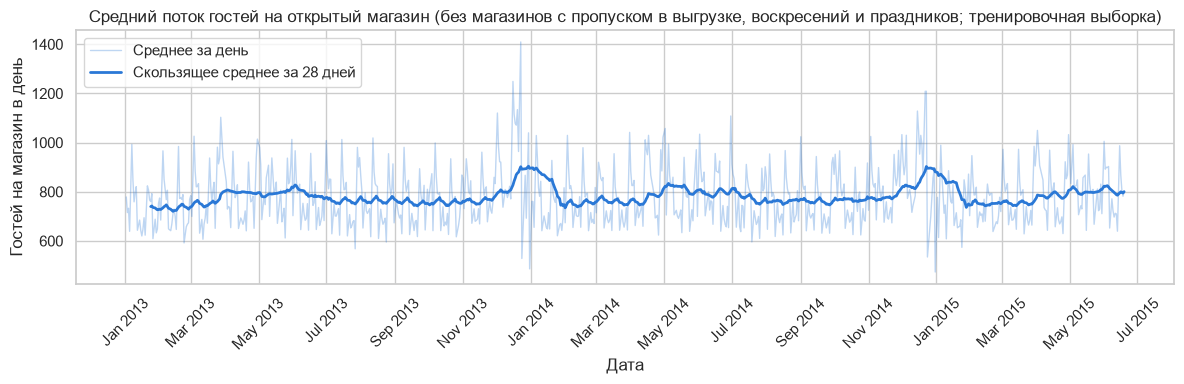

Рост сети в целом, окно 01.01–19.06: -0.4%


In [33]:
network = (open_train[~open_train["Store"].isin(gap_stores)
                      & open_train["Date"].dt.dayofweek.lt(6)
                      & open_train["StateHoliday"].eq("0")]
           .groupby("Date")["Customers"].mean())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(network.index, network, color="#2a78d6", alpha=0.3, linewidth=1, label="Среднее за день")
ax.plot(network.rolling(28, min_periods=20).mean(), color="#2a78d6", linewidth=2,
        label="Скользящее среднее за 28 дней")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title="Средний поток гостей на открытый магазин (без магазинов с пропуском в выгрузке, воскресений и праздников; тренировочная выборка)",
       xlabel="Дата", ylabel="Гостей на магазин в день")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

network_by_window = {year: network.loc[start:end].mean() for year, (start, end) in growth_windows.items()}
print(f"Рост сети в целом, окно 01.01–19.06: {network_by_window['2015'] / network_by_window['2014'] - 1:+.1%}")

Общего тренда у сети нет: скользящее среднее за 28 дней держится на уровне 750–830 гостей на магазин, а изменение за 01.01–19.06 2015 года к тем же датам 2014 года - всего −0.4%. Зато ряд несет выраженную **годовую сезонность** и **праздничные всплески**, и оба эффекта повторяются из года в год.

**1. Годовая сезонность устойчива.** Картина 2013 и 2014 годов почти одинакова:
  - январь–март - самый низкий уровень количества посетителей (~740–760);
  - апрель–июнь - умеренный подъем (~800–830);
  - лето и осень - ровный уровень (~760–780);
  - декабрь - пик (~900 посетителей в скользящем среднем);
  - сразу после Нового года идет резкий спад.
  
 
**2. Праздничные всплески - это события, а не выбросы.** Отдельные дни перед Рождеством дают до ~1400 гостей на магазин, почти вдвое выше обычного. Сразу после праздников бывают провалы до ~500 (гипотеза: сокращенные дни 24 и 31 декабря; будет проверено на выборке). Удалять такие дни как выбросы нельзя, их нужно описывать календарными признаками.

**3. Колебания от дня ко дню больше сезонных.** Дневное среднее регулярно ходит между ~600 и ~1000, тогда как скользящее среднее меняется за год лишь в пределах ~740–900. Колебания выглядят периодическими, с шагом около двух недель (гипотеза: на это влияют промоакции/реклама `Promo`, которые в сети магазинов Rossmann идут через неделю; будет проверено на выборке). Для прогноза на 7 дней вперед недельный ритм, промоакции и праздники важнее годовой сезонности.

**4. Тестовая выборка (20.06–31.07) приходится на спокойный летний участок**, без сезонного пика. Метрика на тесте покажет качество в "обычный" период. Качество в декабре и в праздники нужно проверять отдельно, на скользящей валидации внутри тренировочной выборки.

**5. Тренд есть только у отдельных магазинов** (более подробно будет исследовано позже), в сумме по сети он не наблюдается, поэтому при отборе будет учитываться рост: иначе тренда в выборке может не оказаться.

### 6.2 Хватает ли открытых дней для расчета роста

Рост считается по среднему на открытый день. Если в одном из окон магазин был долго закрыт, среднее считается по малому числу дней и рост ненадежен. Порог минимального числа открытых дней выбирается по распределению.

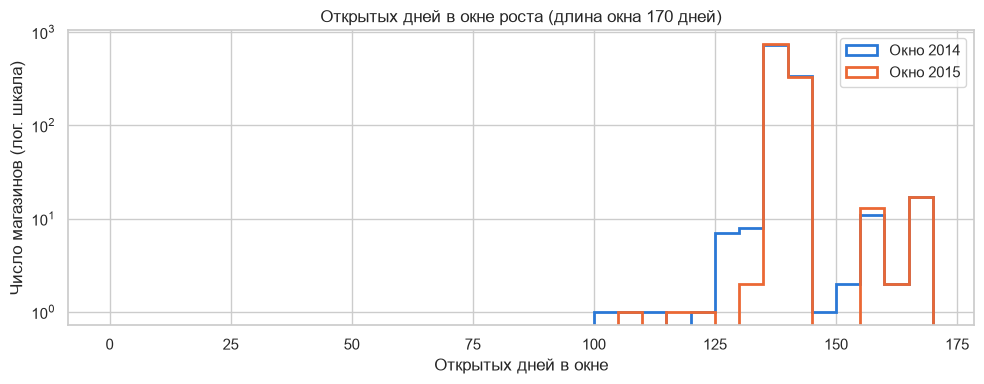

In [34]:
window_len = (growth_windows["2015"][1] - growth_windows["2015"][0]).days + 1

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(0, window_len + 5, 5)
for col, color, label in [("open_days_2014", "#2a78d6", "2014"), ("open_days_2015", "#eb6834", "2015")]:
    ax.hist(profile[col], bins=bins, histtype="step", linewidth=2, color=color, label=f"Окно {label}")
ax.set_yscale("log")
ax.set(title=f"Открытых дней в окне роста (длина окна {window_len} дней)",
       xlabel="Открытых дней в окне", ylabel="Число магазинов (лог. шкала)")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
min_open_days = profile[["open_days_2014", "open_days_2015"]].min(axis=1)
min_open_days.describe().round(1).to_frame("значение")

,значение
count,1115.0
mean,139.4
std,5.1
min,103.0
25%,138.0
50%,139.0
75%,140.0
max,170.0


In [36]:
print(min_open_days.value_counts().sort_index().head(15).to_dict())

{103: 1, 105: 1, 109: 1, 112: 1, 116: 1, 123: 1, 124: 1, 125: 1, 126: 3, 127: 2, 129: 1, 130: 3, 131: 1, 132: 5, 133: 1}


Распределения открытых дней в окнах 2014 и 2015 годов почти совпадают. Значит, окна сопоставимы: в оба попадают одни и те же весенние праздники, и рост год к году не искажен разным числом рабочих дней. На графике четыре группы магазинов:

1. 135-145 открытых дней (из 170) - стандартное расписание работы (из 170 дней вычитаются ~24 воскресенья и ~7 праздников) - около 1000 таких магазинов
2. 155-170 открытых дней (из 170) - магазины, работающие по воскресеньям и праздникам - меньше 50 таких магазинов
3. 123-135 открытых дней (из 170) - магазины, где наблюдается закрытие внутри окна - таких магазинов единицы
4. 103-116 открытых дней (из 170) - магазины, где наблюдаются долгие закрытия внутри окна - 5 магазинов

В 2014 году левый хвост (125–135 дней) заметно больше, чем в 2015-м. Это согласуется с графиком закрытий из блока 4: весной 2014 года было особенно много ремонтов.

**Выбор порога.** Среди малых значений (вывод `value_counts`) есть естественный разрыв: 103, 105, 109, 112, 116 - затем сразу 123 и выше. Порог `MIN_OPEN_DAYS_GROWTH = 120` проходит по этому разрыву. У 5 магазинов ниже порога средний поток за окно считается по заметно меньшему числу дней и часто по дням сразу до или после ремонта, поэтому рост для них ненадежен. Такие магазины получат `growth_yoy = NaN` и пойдут в страту "нет данных". Остальные магазины потеряли в окне не больше ~15 дней, и среднее на открытый день у них устойчиво.

**Ограничение.** Порог абсолютный. У "воскресного" магазина обычное число открытых дней около 165, и тот же порог 120 пропустил бы у него закрытие дольше, чем у обычного магазина. Сейчас это ни на что не влияет: все магазины ниже порога работают по обычному расписанию. Но если поменять окно, порог лучше задавать относительно обычного числа открытых дней магазина.

In [37]:
MIN_OPEN_DAYS_GROWTH = 120

profile["growth_yoy"] = profile["growth_raw"].where(min_open_days >= MIN_OPEN_DAYS_GROWTH)
print(f"Рост не рассчитан (мало открытых дней) у {profile['growth_yoy'].isna().sum()} магазинов")
display(profile.loc[profile["growth_yoy"].isna(),
                    ["StoreType", "open_days_2014", "open_days_2015", "n_long_closures", "growth_raw"]])

Рост не рассчитан (мало открытых дней) у 5 магазинов


,StoreType,open_days_2014,open_days_2015,n_long_closures,growth_raw
Store,,,,,
25,c,112,138,1,-0.007045
644,c,138,116,2,0.017311
674,a,139,105,1,-0.005991
837,a,109,139,1,-0.016121
972,a,103,139,2,-0.020789


Порог отсек 5 магазинов, представленных в таблице, причиной служит долгое закрытие внутри одного из окон. Магазины относятся либо к типу `a`, либо к типу `c. Сырой рост у этих магазинов не экстремальный, внутри центральной половины распределения, значит, порог не исключает интересные случаи тренда.

**Note!** Эти 5 магазинов не исключаются из выборки, они участвуют в отборе в отдельной страте роста "нет данных", а в обязательную группу "длинное закрытие" они могут попасть на общих основаниях.

### 6.3 Распределения характеристик магазинов

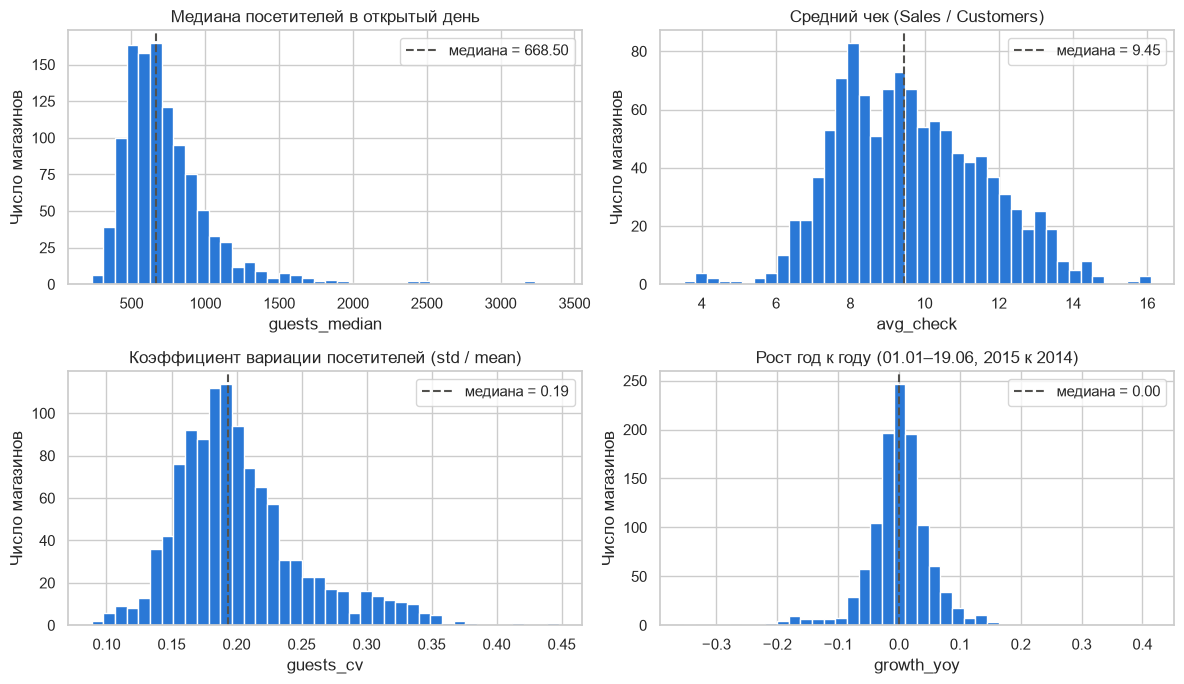

In [38]:
distribution_cols = {
    "guests_median": "Медиана посетителей в открытый день",
    "avg_check": "Средний чек (Sales / Customers)",
    "guests_cv": "Коэффициент вариации посетителей (std / mean)",
    "growth_yoy": "Рост год к году (01.01–19.06, 2015 к 2014)",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, title) in zip(axes.flat, distribution_cols.items()):
    values = profile[col].dropna()
    ax.hist(values, bins=40, color="#2a78d6", edgecolor="white")
    ax.axvline(values.median(), color="#52514e", linestyle="--", linewidth=1.5,
               label=f"медиана = {values.median():.2f}")
    ax.set(title=title, xlabel=col, ylabel="Число магазинов")
    ax.legend()
plt.tight_layout()
plt.show()

In [39]:
profile[list(distribution_cols)].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max
guests_median,1115.0,747.471,350.442,231.000,404.000,537.000,668.500,856.250,1312.500,3394.500
avg_check,1115.0,9.625,1.982,3.508,6.805,8.113,9.445,10.950,13.087,16.090
guests_cv,1115.0,0.202,0.050,0.089,0.138,0.169,0.194,0.224,0.311,0.448
growth_yoy,1110.0,-0.001,0.053,-0.354,-0.075,-0.022,0.000,0.025,0.077,0.413


Распределение **медианы посетителей** скошено вправо: у 90% магазинов (с 5-го по 95-й перцентиль) медиана посетителей от 404 до 1313, однако хвост тянется до 3395 (это магазины типа `b`). Масштаб магазинов сильно различается, и для MAPE и для глобальной модели важно это учитывать.

**Средний чек** имеет распределение, близкое к симметричному - у 90% магазинов средний чек 6.8–13.1 (5–95%).

**Коэффициент вариации посетителей** у 90% магазинов находится в диапазоне 0.14–0.31. То есть у большинства магазинов дневной поток колеблется примерно на 20% вокруг среднего.

**Рост год к году** центрирован на нуле (медиана 0.0%), при этом 5–95% значений в диапазоне от −7.5% до +7.7%, а отдельные магазины доходят до −35% и +41%. Как уже было сказано, тренд наблюдается у отдельных магазинов, причем он разнонаправлен. У сети четкого тренда нет.

### 6.4 Сколько дней магазин открыт в тесте

Так как расписание праздников и выходных известно заранее, то это не является утечкой. Отсюда можно эмпирически получить фильтр для отбора выборки.

открытых дней в тесте,18,22,31,36,37,42
магазинов,1,2,1,1078,1,32


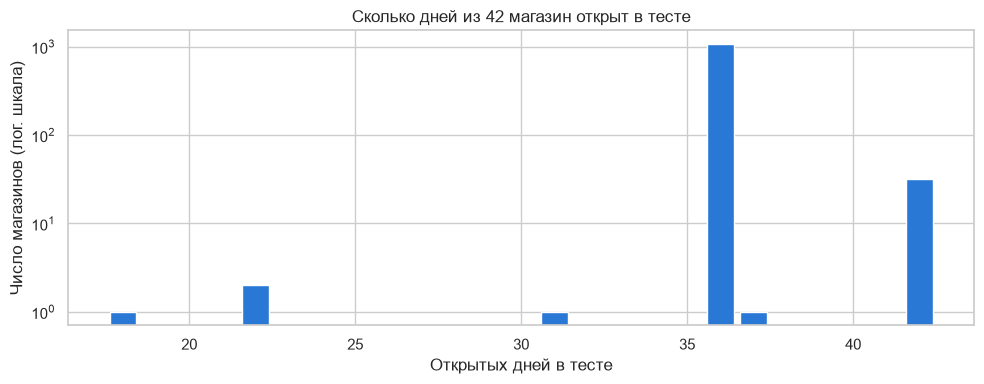

,StoreType,open_days_test,sunday_open_days,closed_in_test
Store,,,,
183,a,31,0,True
292,a,18,0,True
876,a,22,0,True
909,a,22,0,True


In [40]:
open_days_test_counts = profile["open_days_test"].value_counts().sort_index()
display(open_days_test_counts.rename_axis("открытых дней в тесте").to_frame("магазинов").T)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(open_days_test_counts.index, open_days_test_counts.values, color="#2a78d6")
ax.set_yscale("log")
ax.set(title=f"Сколько дней из {len(test_days)} магазин открыт в тесте",
       xlabel="Открытых дней в тесте", ylabel="Число магазинов (лог. шкала)")
plt.tight_layout()
plt.show()

profile.loc[profile["open_days_test"] < open_days_test_counts.idxmax(),
            ["StoreType", "open_days_test", "sunday_open_days", "closed_in_test"]]

Расписание работы в тестовой выборке почти у всех магазинов одинаковое:
* 1078 магазинов работают все дни, кроме воскресений
* 32 магазина работают и по воскресеньям
* 1 магазин работает 37 дней
* 4 магазина закрыты на ремонт (исследовано в блоке 4.2) - они относятся к типу магазинов a.

Эмпирический фильтр: **исключаем магазины с длинным закрытием в тесте**. Отдельный порог по числу открытых дней не нужен: он исключает те же 4 магазина.

### 6.5 Масштаб, чек и вариативность

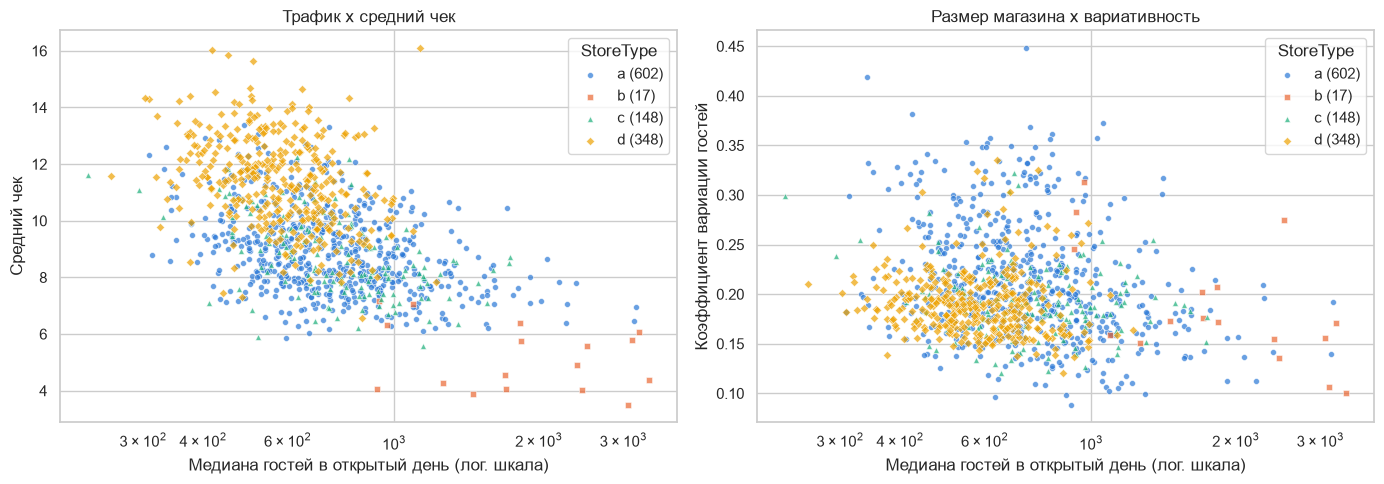

Корреляция Спирмена: трафик x чек = -0.52, трафик × CV = -0.19


In [41]:
STORE_TYPE_STYLE = {
    "a": ("#2a78d6", "o"), "b": ("#eb6834", "s"), "c": ("#1baf7a", "^"), "d": ("#eda100", "D"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for store_type, (color, marker) in STORE_TYPE_STYLE.items():
    part = profile[profile["StoreType"] == store_type]
    for ax, y_col in zip(axes, ["avg_check", "guests_cv"]):
        ax.scatter(part["guests_median"], part[y_col], s=18, color=color, marker=marker,
                   alpha=0.7, edgecolor="white", linewidth=0.5, label=f"{store_type} ({len(part)})")
for ax, y_label, title in zip(
        axes,
        ["Средний чек", "Коэффициент вариации гостей"],
        ["Трафик x средний чек", "Размер магазина x вариативность"]):
    ax.set_xscale("log")
    ax.set(title=title, xlabel="Медиана гостей в открытый день (лог. шкала)", ylabel=y_label)
    ax.legend(title="StoreType")
plt.tight_layout()
plt.show()

print(f"Корреляция Спирмена: трафик x чек = "
      f"{profile['guests_median'].corr(profile['avg_check'], method='spearman'):.2f}, "
      f"трафик × CV = {profile['guests_median'].corr(profile['guests_cv'], method='spearman'):.2f}")

Для распределения среднего чека и медианы посетителей наблюдается умеренная отрицательная монотонная связь (корреляция Спирмена равна -0.52). То есть чем больше магазин по количеству посетителей, тем ниже средний чек.
На графике видно несколько групп:
* магазины типа `b` - это аналог фастфуда (много посетителей и низкий чек);
* магазины типа `d` - это дорогой сегмент (гостей немного, средний чек высокий);
* магазины типа `a` и `c` - это средний сегмент, причем на графике эти типы наслаиваются друг на друга.

Что касается распределения медианы посетителей и вариативности, наблюдается слабая отрицательная связь между масштабом магазина и относительной вариативностью потока (коэффициент корреляции -0.19). Дорогой сегмент (магазины типа d) более стабилен, значения сосредоточены вокруг коэффициента вариативности 0.2, средний сегмент рассредоточен. 

Для метрик это значит, что у мелких магазинов MAPE ожидаемо выше, а MAE ниже, поэтому сравнивать их нужно по группам.

## 7. Какие характеристики магазина связаны со спросом

Стратифицировать имеет смысл только по тем характеристикам, которые связаны со спросом: иначе стратификация усложняет отбор и ничего не дает. Кандидаты: `StoreType`, `Assortment`, `Promo2`, расстояние до конкурента (квартили) и флаг "конкурент открылся внутри трейна". Для каждой анализируется уровень спроса (медиана гостей), средний чек и рост.

Сила связи измеряется мерой **$\epsilon^2$ из критерия Краскела–Уоллиса**: доля разброса рангов, объясненная группами (0 - связи нет, 1 - группы полностью разделяют магазины). Ранговый критерий выбран потому, что распределения скошены.

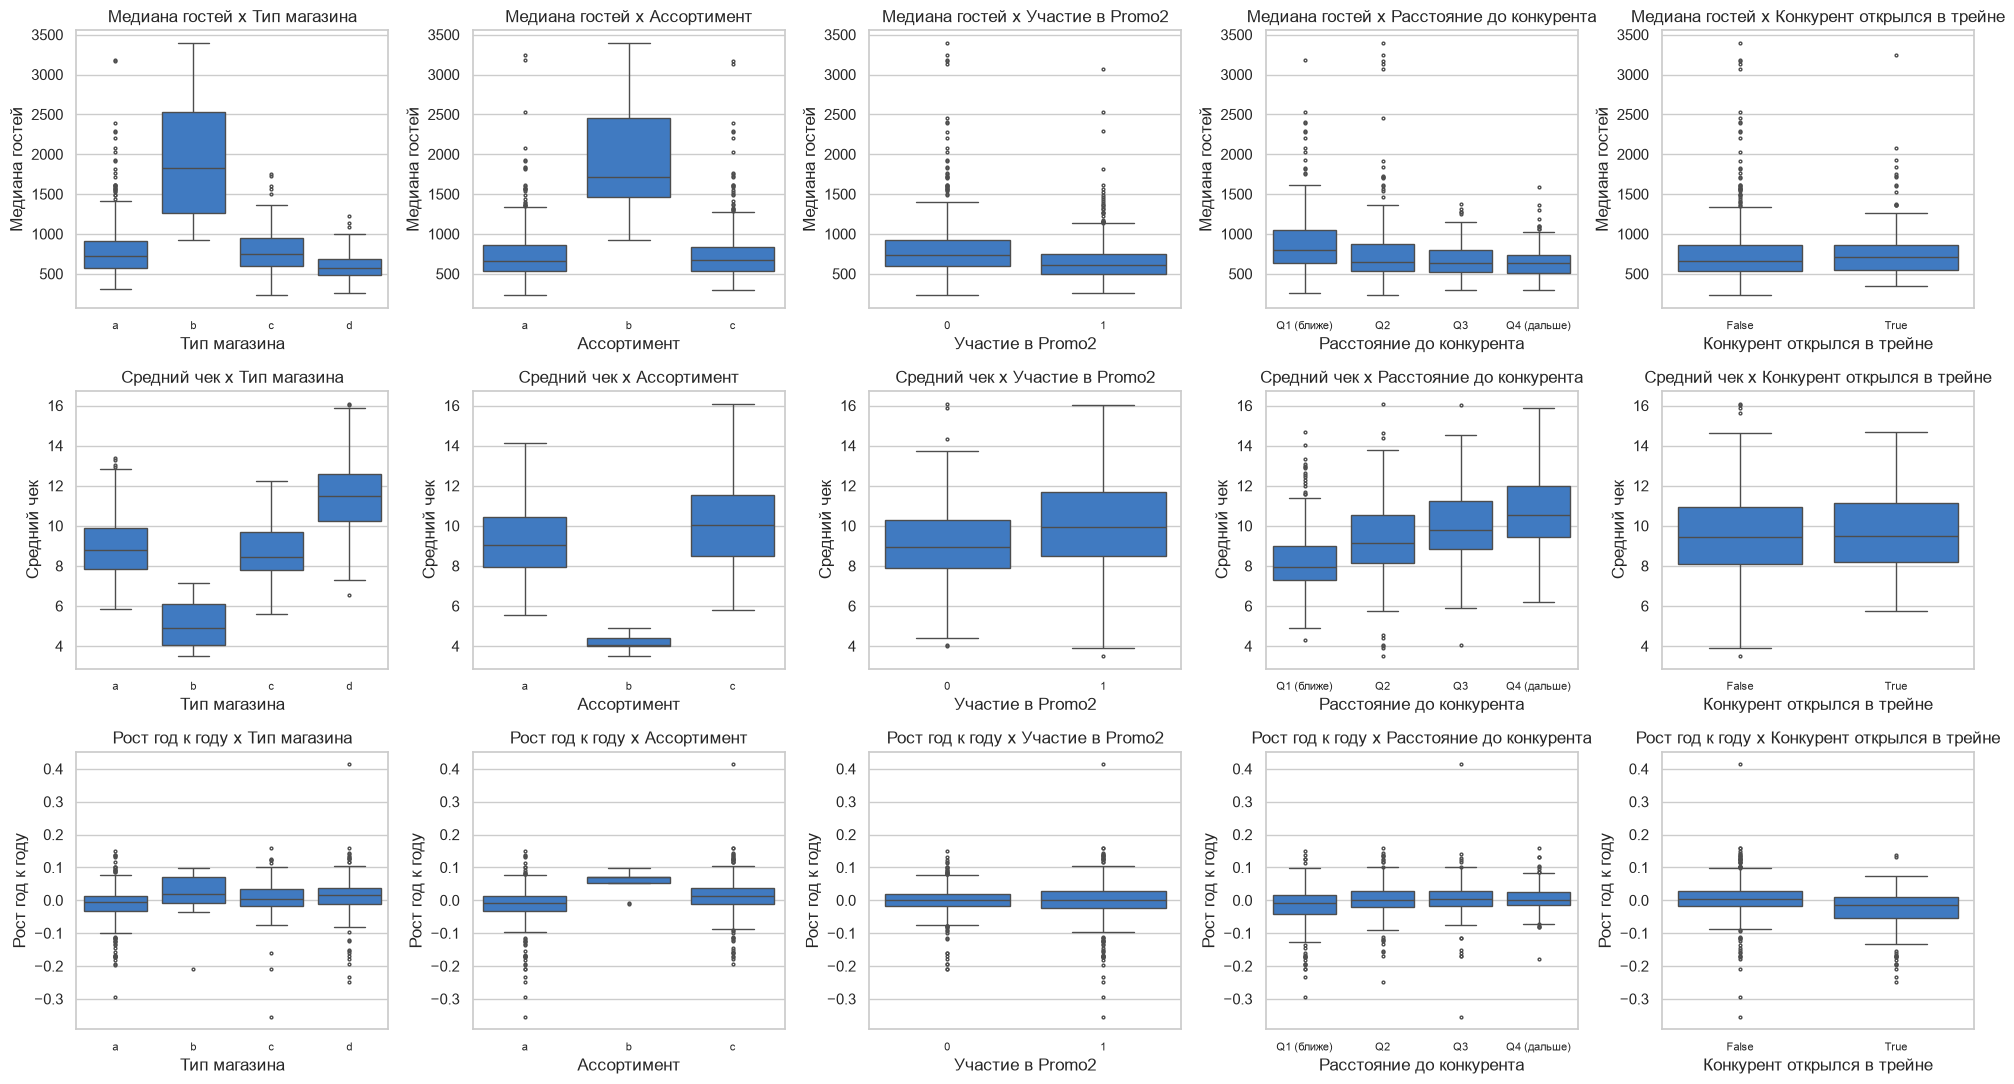

In [42]:
profile["distance_quartile"] = pd.qcut(profile["CompetitionDistance"], 4,
                                       labels=["Q1 (ближе)", "Q2", "Q3", "Q4 (дальше)"])
candidate_features = {
    "StoreType": "Тип магазина",
    "Assortment": "Ассортимент",
    "Promo2": "Участие в Promo2",
    "distance_quartile": "Расстояние до конкурента",
    "competitor_opened_in_train": "Конкурент открылся в трейне",
}
target_cols = {"guests_median": "Медиана гостей", "avg_check": "Средний чек", "growth_yoy": "Рост год к году"}

fig, axes = plt.subplots(len(target_cols), len(candidate_features), figsize=(20, 11))
for row, (target, target_title) in zip(axes, target_cols.items()):
    for ax, (feature, feature_title) in zip(row, candidate_features.items()):
        order = None if isinstance(profile[feature].dtype, pd.CategoricalDtype) else sorted(profile[feature].unique())
        sns.boxplot(data=profile, x=feature, y=target, order=order, ax=ax, color="#2a78d6", fliersize=2)
        ax.set(title=f"{target_title} х {feature_title}", xlabel=feature_title, ylabel=target_title)
        ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

Сильнее всего магазины различаются по **типу**. К предыдущему выводу о разных сегментах стоит добавить, что по роску год к году различия между типами магазинов небольшие: у типа `a` медиана чуть ниже нуля, у типов `b` и `d` - чуть выше.

**Ассортимент** в основном повторяет тип: ассортимент `b` есть только у магазинов типа `b`, поэтому его "выброс" по потоку и чеку - это тот же тип `b`. Между ассортиментами `a` и `c` поток одинаковый, а чек у `c` немного выше. Заметный рост у ассортимента `b` (около +6%) опирается всего на 9 магазинов, и делать из него выводы некорректно.

**Участники Promo2** в среднем меньше по потоку (около 600 гостей против 750) при чуть более высоком чеке, а рост у обеих групп одинаковый. Скорее всего, это эффект отбора, а не действие акции: в Promo2 чаще включают менее посещаемые магазины. Причинно-следственный вывод отсюда делать нельзя.

**Расстояние до конкурента** дает самую последовательную картину. Чем ближе конкурент, тем больше гостей и тем ниже чек: медиана чека растет от квартиля к квартилю примерно с 8 до 10.5. Близкий конкурент - это вероятно, признак плотной центральной локации с большим потоком "быстрых" покупок, а не причина высокого спроса. У ближайшего квартиля рост немного ниже, а хвост падений длиннее.

**Открытие конкурента внутри периода тренировочной выборки** не связано ни с уровнем потока, ни с чеком: магазины, у которых конкурент появился недавно, по масштабу такие же, как остальные. Но их рост заметно ниже - вся коробка сдвинута вниз, медиана слегка отрицательная. Это ожидаемый эффект нового конкурента, и его стоит разобрать на выборке.

Почти на всех графиках много верхних выбросов по потоку: это отдельные очень крупные магазины. У роста длинные хвосты в обе стороны, то есть у отдельных магазинов есть и сильный рост, и сильное падение.

In [43]:
def epsilon_squared(frame: pd.DataFrame, group_col: str, value_col: str) -> float:
    groups = [values.dropna() for _, values in frame.groupby(group_col, observed=True)[value_col]]
    groups = [g for g in groups if len(g) > 0]
    h_stat, _ = kruskal(*groups)
    return h_stat / (sum(len(g) for g in groups) - 1)


association = pd.DataFrame(
    {target: {feature: epsilon_squared(profile, feature, target) for feature in candidate_features}
     for target in target_cols}
).rename(columns=target_cols)
association.round(3).sort_values("Медиана гостей", ascending=False)

,Медиана гостей,Средний чек,Рост год к году
StoreType,0.148,0.386,0.069
distance_quartile,0.083,0.229,0.027
Promo2,0.078,0.060,0.000
Assortment,0.021,0.072,0.087
competitor_opened_in_train,0.002,0.001,0.045


**Вывод по силе связи.** При 1 115 магазинах почти любое различие между группами окажется статистически значимым, поэтому p-значение здесь мало что говорит. Решение принимается по размеру эффекта $\epsilon^2$. Шкала следующая: до 0.01 - связи практически нет, 0.01–0.08 - слабая, 0.08–0.26 - умеренная, выше 0.26 - сильная.

**Тип магазина** - единственная характеристика с сильной связью: тип магазина объясняет 39% разброса рангов среднего чека ($\epsilon^2$ = 0.386) и умеренно связан с потоком (0.148). С ростом связь слабая (0.069).

**Расстояние до конкурента** - вторая по силе характеристика: умеренная связь с чеком (0.229) и на границе умеренной с потоком (0.083), с ростом почти не связано (0.027). **Promo2** слабо связан с потоком (0.078) и чеком (0.060) и не связан с ростом совсем (0.000).

**Ассортимент** почти ничего не добавляет к уровню потока (0.021), зато из всех характеристик сильнее всего связан с ростом (0.087). Но эта связь держится на ассортименте `b`, то есть на 9 магазинах типа `b`, и потому ненадежна. 

**Открытие конкурента внутри трейна** не связано ни с потоком, ни с чеком (0.002 и 0.001), но слабо связано с ростом (0.045) - это согласуется со сдвигом коробки вниз на графике.

**Решение для отбора.** Стратификация по сегменту на основе типа магазина: это самая сильная и при этом интерпретируемая характеристика. Вторая ось стратификации - терциль роста, чтобы в выборке был тренд. Расстояние до конкурента и Promo2 связаны со спросом слабее, а ассортимент во многом дублирует тип. Если добавить их в страты, на 40 магазинов получится слишком много мелких ячеек. Поэтому эти характеристики не стратифицируем, а проверяем через баланс выборки. Открытие конкурента уже гарантировано обязательной группой отбора.

## 8. Сегменты

Сегменты нужны для трех вещей: квот при отборе (в каждом сегменте должно хватить магазинов), метрик по группам и эксперимента "модель на сегмент". По аналогии с ресторанами сегмент определяется трафиком и средним чеком. Сравниваем профиль типов магазинов по этим характеристикам.

In [44]:
(profile.groupby("StoreType")
 .agg(магазинов=("guests_median", "size"),
      медиана_гостей=("guests_median", "median"),
      средний_чек=("avg_check", "median"),
      cv=("guests_cv", "median"),
      рост=("growth_yoy", "median"),
      доля_воскресных=("sunday_open", "mean"))
 .round(3))

,магазинов,медиана_гостей,средний_чек,cv,рост,доля_воскресных
StoreType,,,,,,
a,602,722.00,8.793,0.201,-0.006,0.022
b,17,1833.00,4.920,0.172,0.019,1.000
c,148,744.00,8.440,0.191,0.005,0.000
d,348,576.75,11.464,0.187,0.015,0.009


По сводной таблице типы магазинов делятся на три группы, а не на четыре (подтверждает такой вывод, сделанный ранее). Тип `b` резко отличается от остальных: медиана около 1 830 гостей в день, в 2.5 раза больше типичного магазина, и самый низкий средний чек (4.9). Кроме того, все 17 магазинов этого типа работают по воскресеньям, а поток у них самый стабильный (коэффициент вариации 0.17): крупные магазины колеблются меньше. Тип `d` — противоположный полюс: самый малый поток (около 580 гостей) и самый высокий чек (11.5). Типы `a` и `c` почти совпадают: около 720 и 740 гостей, чек 8.8 и 8.4, одинаковая вариативность. По воскресеньям из них работают единичные магазины. По росту типы различаются слабо: от −0.6% у `a` до +1.9% у `b`. Еще раз подтверждается, что тренд - свойство отдельных магазинов, а не типа.

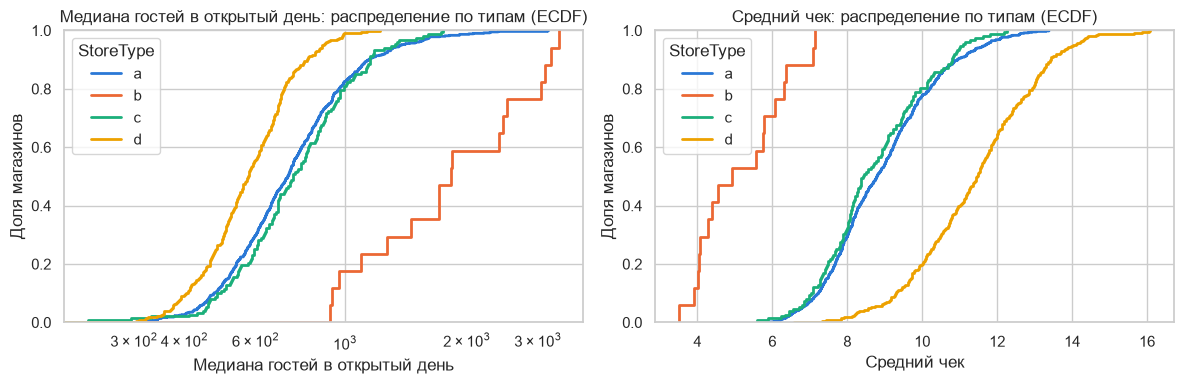

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, title) in zip(axes, [("guests_median", "Медиана гостей в открытый день"),
                                   ("avg_check", "Средний чек")]):
    for store_type, (color, _) in STORE_TYPE_STYLE.items():
        sns.ecdfplot(profile.loc[profile["StoreType"] == store_type, col], ax=ax, color=color,
                     linewidth=2, label=store_type)
    ax.set(title=f"{title}: распределение по типам (ECDF)", xlabel=title, ylabel="Доля магазинов")
    ax.legend(title="StoreType")
axes[0].set_xscale("log")
plt.tight_layout()
plt.show()

Графики подтверждают, что различия касаются не только медиан, но и распределений целиком. Кривые `a` и `c` почти накладываются друг на друга и по потоку, и по чеку, поэтому разделять их нет оснований. Кривая `d` сдвинута влево по потоку и заметно вправо по чеку: по потоку `d` частично пересекается с `a` и `c`, но по чеку отделен от них гораздо лучше. Тип `b` отделен почти полностью: даже самый малый магазин `b` крупнее большинства остальных магазинов, а чек у всех магазинов `b` ниже, чем у подавляющего большинства прочих.

**`a` и `c` объединяются в один сегмент.**

In [46]:
SEGMENT_MAP = {"b": "high_traffic", "a": "mid", "c": "mid", "d": "high_check"}

profile["segment"] = profile["StoreType"].map(SEGMENT_MAP)
(profile.groupby("segment")
 .agg(магазинов=("guests_median", "size"), медиана_гостей=("guests_median", "median"),
      средний_чек=("avg_check", "median"))
 .assign(доля=lambda d: (d["магазинов"] / d["магазинов"].sum()).round(3))
 .round(2))

,магазинов,медиана_гостей,средний_чек,доля
segment,,,,
high_check,348,576.75,11.46,0.31
high_traffic,17,1833.00,4.92,0.02
mid,750,727.00,8.75,0.67


Получаются следующие сегменты, которые по аналогии с ресторанами различаются сочетанием трафика и чека:

- `mid` (типы `a` и `c`) — 750 магазинов, 67% сети: средний сегмент, около 730 гостей, чек 8.75;
- `high_check` (тип `d`) — 348 магазинов, 31%: меньше гостей (около 580), выше чек (11.5), аналог более дорогого заведения;
- `high_traffic` (тип `b`) — 17 магазинов, 1.5%: много гостей (около 1 830), низкий чек (4.9), аналог фастфуда.

Сегмент будет строиться по типу магазина, а не по кластеризации трафика и чека. Причины три. Тип - статичная характеристика из `store.csv`: он известен заранее, в том числе для магазина без истории. Он не зависит от целевой переменной. И его легко объяснить. Кластеры по потоку пришлось бы пересчитывать при изменении данных, а граница между `mid` и `high_check` по потоку все равно размыта.

**Что это значит для дальнейшей работы.** Сегмент `high_traffic` очень маленький: при пропорциональном отборе из 40 магазинов ему досталось бы меньше одного магазина. Поэтому в отборе для него задан минимум в 5 магазинов. Этого хватит, чтобы посчитать метрику по сегменту, но для отдельной модели на сегмент данных будет мало. Кроме того, внутри сегментов масштаб магазинов по-прежнему сильно различается. Сегмент не заменяет нормировку на уровень конкретного магазина, поэтому глобальной модели все равно понадобятся признаки масштаба магазина. И наконец, у `high_traffic` недельный цикл ближе всего к ресторанному: все такие магазины работают по воскресеньям. Именно на них будет проверяться, как модель справляется с полной неделей.

## 9. Правила отбора

Все параметры отбора ниже выведены из блоков 2–8 и **фиксируются до отбора**.

Критерий баланса для проверки в разделе 10: выборка должна быть не хуже простой случайной выборки того же размера - максимальное SMD не больше 95-го перцентиля максимального SMD у случайных выборок. Сам порог выводится в разделе 10.2 только из размера выборки и пула магазинов, поэтому не зависит от того, какие магазины отобраны. Если критерий не выполнится, меняется правило.

1. **Жесткий фильтр:** исключаем магазины с длинным закрытием в тесте (подробнее в разделах 4.2 и 6.4) - прогнозировать закрытый магазин бессмысленно.
2. **Обязательные включения** - редкие, но интересные случаи:
   * 1 магазин, появившийся в данных позже (закрыт с первого дня данных): случай "точки нет в этот период" в буквальном смысле, в сети таких магазинов всего 4;
   * по 3 магазина с аномалиями "открыт, но 0 гостей" (считаются только по тренировочной выборке), с пробелом в выгрузке, с длинным закрытием и с открытием конкурента внутри периода тренировочных данных.

    Этих случаев в сети немного, и случайная выборка может их не содержать. Квоты накопительные - "не меньше N магазинов в группе": магазин, отобранный в одну группу, засчитывается и во все остальные группы, к которым он относится. Их доля в выборке выше, чем в сети, поэтому метрики потом будут считаться и в целом, и по группам.
3. **Добор до размера выборки** стратифицированной случайной выборкой: `сегмент х терциль` роста (подробнее в разделах 7-8). Квоты по сегментам пропорциональны их размеру в сети; сегмент, чья пропорциональная квота меньше минимума, поднимается до минимума за счет остальных: иначе сегмент с высоким трафиком (1.5% сети, меньше одного магазина из 40) вообще не попадет в выборку. Внутри сегмента квоты распределяются пропорционально терцилям роста.
4. **Воспроизводимость:** генератор `np.random.default_rng(SEED)`, магазины в пулах упорядочены по номеру.

In [47]:
SEED = 42
SUBSET_SIZE = 40
MANDATORY_GROUPS = {
    "has_left_censored": 1,
    "has_anomaly": 3,
    "has_export_gap": 3,
    "has_long_closure": 3,
    "competitor_opened_in_train": 3,
}
MIN_PER_SEGMENT = 5
BALANCE_LEVEL = 0.95

eligible = profile[~profile["closed_in_test"]].copy()
eligible["has_anomaly"] = eligible["n_anomalies"] > 0
eligible["growth_tercile"] = (pd.qcut(eligible["growth_yoy"], 3, labels=["падение", "стабильно", "рост"])
                              .cat.add_categories("нет данных")
                              .fillna("нет данных"))
print(f"Исключено жестким фильтром (закрыт в тесте): {sorted(profile.index[profile['closed_in_test']])}")
print(f"Доступно для отбора: {len(eligible)} магазинов")
eligible.groupby("growth_tercile", observed=True)["growth_yoy"].agg(["size", "min", "max"]).round(3)

Исключено жестким фильтром (закрыт в тесте): [183, 292, 876, 909]
Доступно для отбора: 1111 магазинов


,size,min,max
growth_tercile,,,
падение,369,-0.354,-0.013
стабильно,368,-0.013,0.015
рост,369,0.015,0.413
нет данных,5,NaN,NaN


In [48]:
def proportional_quota(sizes: pd.Series, total: int, minimum: int = 0) -> pd.Series:
    # Квоты пропорционально размерам групп (метод наибольших остатков).
    # Группы, чья пропорциональная доля меньше minimum, поднимаются до minimum за счет остальных.
    raised = sizes.index[sizes / sizes.sum() * total < minimum]
    quota = pd.Series(0, index=sizes.index)
    quota[raised] = np.minimum(minimum, sizes[raised])
    rest = sizes.drop(raised)
    exact = rest / rest.sum() * (total - quota.sum())
    quota[rest.index] = np.floor(exact).astype(int)
    leftover = int(total - quota.sum())
    quota[(exact - np.floor(exact)).sort_values(ascending=False).index[:leftover]] += 1
    return quota


def select_stores(pool: pd.DataFrame, size: int, seed: int) -> pd.Series:
    # Возвращает причину включения для каждого выбранного магазина
    rng = np.random.default_rng(seed)
    reasons = pd.Series(dtype=str)

    for flag, needed in MANDATORY_GROUPS.items():
        already = pool.loc[pool.index.isin(reasons.index), flag].sum()
        candidates = pool.index[pool[flag] & ~pool.index.isin(reasons.index)].sort_values()
        picked = rng.choice(candidates, size=max(needed - already, 0), replace=False)
        reasons = pd.concat([reasons, pd.Series(f"обязательный: {flag}", index=picked)])

    segment_quota = proportional_quota(pool["segment"].value_counts(), size, minimum=MIN_PER_SEGMENT)
    for segment, seg_quota in segment_quota.items():
        seg_pool = pool[pool["segment"] == segment]
        chosen = seg_pool.index.isin(reasons.index)
        tercile_target = proportional_quota(seg_pool["growth_tercile"].value_counts(), seg_quota)
        deficit = (tercile_target - seg_pool.loc[chosen, "growth_tercile"].value_counts()
                   .reindex(tercile_target.index, fill_value=0)).clip(lower=0)
        while deficit.sum() > max(seg_quota - chosen.sum(), 0):     # обязательные уже заняли часть квоты
            deficit[deficit.idxmax()] -= 1
        for tercile, needed in deficit[deficit > 0].items():
            candidates = seg_pool.index[(seg_pool["growth_tercile"] == tercile) & ~chosen].sort_values()
            picked = rng.choice(candidates, size=needed, replace=False)
            reasons = pd.concat([reasons, pd.Series("стратифицированный добор", index=picked)])
    return reasons.rename("reason")


selection_reason = select_stores(eligible, SUBSET_SIZE, SEED)
subset = eligible.loc[selection_reason.index].join(selection_reason).sort_index()

print(f"Отобрано магазинов: {len(subset)}")
display(subset["reason"].value_counts().to_frame("магазинов"))
display(subset.loc[subset["reason"].ne("стратифицированный добор"),
                   ["reason", *MANDATORY_GROUPS]])
pd.crosstab(subset["segment"], subset["growth_tercile"], margins=True, margins_name="всего")

Отобрано магазинов: 40


,магазинов
reason,
стратифицированный добор,31
обязательный: has_export_gap,3
обязательный: has_anomaly,3
обязательный: competitor_opened_in_train,2
обязательный: has_left_censored,1


,reason,has_left_censored,has_anomaly,has_export_gap,has_long_closure,competitor_opened_in_train
100,обязательный: has_export_gap,False,False,True,True,False
103,обязательный: has_left_censored,True,False,False,True,True
186,обязательный: has_export_gap,False,False,True,False,False
589,обязательный: has_anomaly,False,True,False,True,False
700,обязательный: has_anomaly,False,True,False,True,False
736,обязательный: has_export_gap,False,False,True,False,False
801,обязательный: competitor_opened_in_train,False,False,False,False,True
850,обязательный: has_anomaly,False,True,False,True,False
1075,обязательный: competitor_opened_in_train,False,False,False,False,True


growth_tercile,падение,стабильно,рост,всего
segment,,,,
high_check,3,3,5,11
high_traffic,1,1,3,5
mid,9,9,6,24
всего,13,13,14,40


Отобрано 40 магазинов: 9 обязательных и 31 добран стратифицированной выборкой. Обязательные квоты накопительные - "не меньше N магазинов в группе", поэтому магазинов с причиной "обязательный" меньше, чем в сумме задано квотами. 

В итоге группа "длинное закрытие" заполнилась без отдельного отбора, а для группы "открытие конкурента" потребовалось добрать только 2 магазина.

Состав по сегментам (24 / 11 / 5) и терцилям роста (13 / 13 / 14) воспроизводит структуру сети: квоты пропорциональны, и только сегмент `high_traffic` поднят до минимума в 5 магазинов. Терцили глобальные, поэтому внутри сегментов распределены неравномерно - в `high_check` растущих магазинов больше, в `mid` больше снижающихся, - и выборка сохраняет это соотношение. Терцили относительные: граница "падения" (−1.3% за полгода) близка к нулю, поэтому группа "падение" означает "хуже медианы", а не обязательно реальное снижение.

## 10. Проверка выборки

### 10.1 Баланс: похожа ли выборка на сеть

Для проверки выборки используется **SMD** (стандартизированная разница средних): разница средних выборки и всех доступных магазинов, деленная на объединенное стандартное отклонение. Для флагов и категорий считается по долям. Критерий баланса описан в разделе 9, сам порог выводится в разделе 10.2.

Часть характеристик перекошена согласно дизайну исследования: проблемные группы и минимум для сегмента с высоким трафиком были добавлены специально. Сегмент `high_traffic` (магазин типа `b`) сильно отличается по масштабу, поэтому SMD считается дважды: по всей выборке и без сегмента `high_traffic`. Критерий проверяется по второму столбцу.

In [49]:
def smd(sample: pd.Series, population: pd.Series) -> float:
    sample, population = sample.dropna().astype(float), population.dropna().astype(float)
    pooled_std = np.sqrt((sample.var() + population.var()) / 2)
    return (sample.mean() - population.mean()) / pooled_std if pooled_std > 0 else 0.0


def balance_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return pd.concat([
        frame[["guests_median", "avg_check", "guests_cv", "growth_yoy"]],
        np.log10(frame["CompetitionDistance"]).rename("log10_competition_distance"),
        frame[["Promo2", "competitor_opened_in_train", "has_export_gap",
               "has_long_closure", "sunday_open"]].astype(int),
        pd.get_dummies(frame["StoreType"], prefix="StoreType").astype(int),
        pd.get_dummies(frame["Assortment"], prefix="Assortment").astype(int),
    ], axis=1)


BY_DESIGN = {"competitor_opened_in_train", "has_export_gap", "has_long_closure",
             "StoreType_b", "Assortment_b", "sunday_open"}

population_features = balance_frame(eligible)
subset_features = balance_frame(subset).reindex(columns=population_features.columns, fill_value=0)
balance = pd.DataFrame({
    "вся сеть": population_features.mean(),
    "выборка": subset_features.mean(),
    "SMD": [smd(subset_features[c], population_features[c]) for c in population_features.columns],
})


population_core = eligible["segment"].ne("high_traffic")
subset_core = subset["segment"].ne("high_traffic")
balance["SMD без high_traffic"] = [smd(subset_features.loc[subset_core, c], population_features.loc[population_core, c])
                                   for c in population_features.columns]
balance["по дизайну"] = balance.index.isin(BY_DESIGN)
balance.round(3)

,вся сеть,выборка,SMD,SMD без high_traffic,по дизайну
guests_median,747.121,812.400,0.172,-0.003,False
avg_check,9.628,9.323,-0.139,0.078,False
guests_cv,0.202,0.198,-0.086,-0.128,False
growth_yoy,-0.001,0.000,0.013,0.027,False
log10_competition_distance,3.318,3.270,-0.068,0.018,False
Promo2,0.512,0.600,0.176,0.288,False
competitor_opened_in_train,0.162,0.200,0.098,0.165,True
has_export_gap,0.160,0.225,0.164,0.234,True
has_long_closure,0.080,0.225,0.408,0.294,True
sunday_open,0.030,0.125,0.359,-0.172,True


В рамках проверки сбалансированности можно сделать следующие выводы:

**По всей собранной выборке** сильнее всего расходятся характеристики, которые перекошены по дизайну исследования:
* доля магазинов типа `b` (SMD = 0.44), ассортимента `b` (0.25) и воскресных магазинов (0.36): в выборке 5 магазинов типа `b` вместо пропорциональных 0.6, а все они работают по воскресеньям;
* доля магазинов с долгими закрытиями (22.5% против 8% в сети, SMD = 0.41) и с пробелом в выгрузке (22.5% против 16%, SMD = 0.16): это обязательные группы, к тому же долгие закрытия есть и у магазинов, отобранных за аномалии, и у магазина, появившегося в данных позже.

Масштаб и средний чек по всей выборке сдвинуты умеренно (SMD = 0.17 и −0.14) - тоже за счет крупных магазинов `high_traffic` с низким чеком.

**Без группы `high_traffic`** отклонения по масштабу, чеку, вариативности, росту, расстоянию до конкурента, типам магазинов и ассортименту небольшие - не больше 0.13 по модулю. **Самое крупное отклонение - по `Promo2`** (SMD = 0.29): участников Promo2 в выборке больше, чем в сети (по всей выборке 60% против 51%).

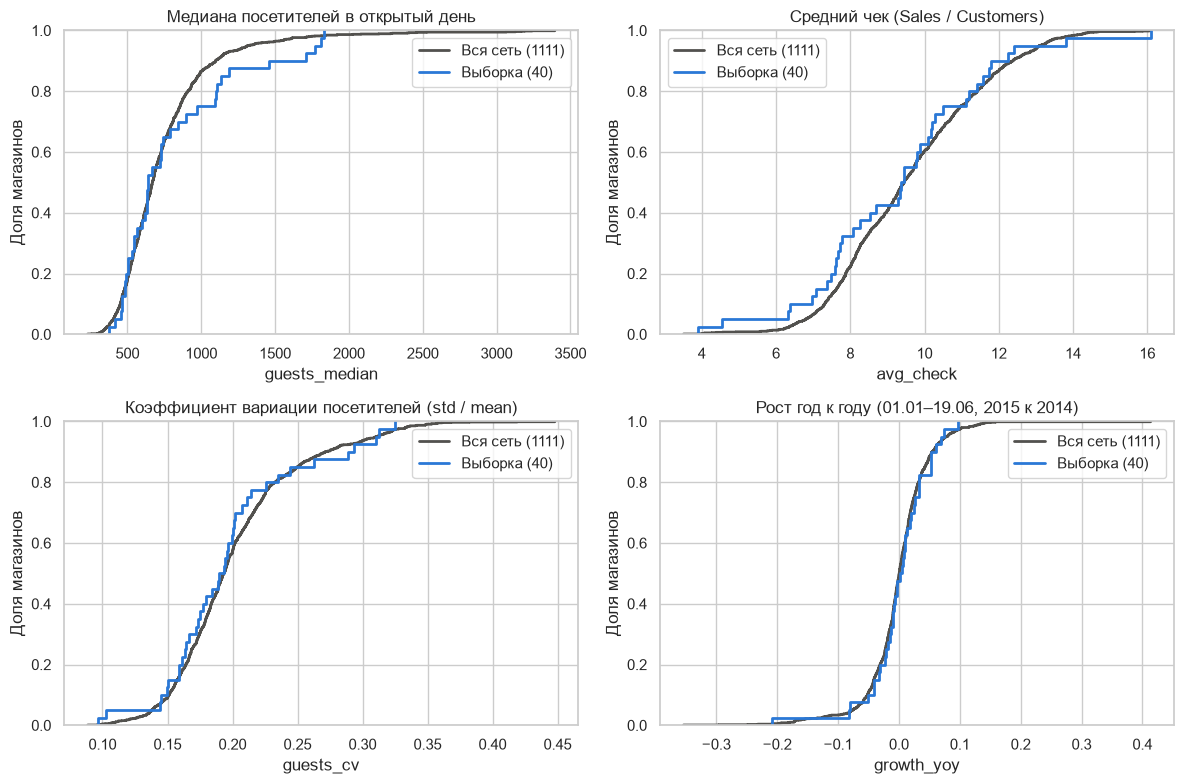

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes.flat, distribution_cols.items()):
    sns.ecdfplot(eligible[col].dropna(), ax=ax, color="#52514e", linewidth=2, label=f"Вся сеть ({len(eligible)})")
    sns.ecdfplot(subset[col].dropna(), ax=ax, color="#2a78d6", linewidth=2, label=f"Выборка ({len(subset)})")
    ax.set(title=title, xlabel=col, ylabel="Доля магазинов")
    ax.legend()
plt.tight_layout()
plt.show()

**Графики ECDF** подтверждают баланс. По среднему чеку, вариативности и росту кривые выборки и сети почти совпадают. По медиане гостей выборка совпадает с сетью примерно до 700 гостей, а выше у нее тяжелее хвост за счет магазинов типа `b`; при этом самых крупных магазинов сети (больше ~1 800 гостей в день) в выборке нет. По среднему чеку отличается только левый хвост - низкий чек магазинов типа `b`. По росту в выборку попал магазин с сильным падением (около −21%), а сильного роста (выше ~+10%) в выборке нет.

Насколько отклонения выходят за рамки случайности, проверяется далее.

### 10.2 Какой разброс SMD возникает из-за размера выборки

Даже при обычном случайном отборе характеристики небольшой выборки не совпадают с характеристиками всей сети точно: маленькая выборка сама по себе дает случайные отклонения. Поэтому порог баланса выводится из размера выборки.

Для этого 500 раз случайно выбирается из того же пула (без `high_traffic`) столько же магазинов, сколько в нашей выборке без `high_traffic`, и для каждой случайной выборки считается максимальное |SMD| по всем признакам. Признаки проверяются одновременно, поэтому критерий совместный: **максимальное |SMD| нашей выборки должно быть не больше 95-го перцентиля максимального |SMD| у случайных выборок**. Порог зависит только от размера выборки и пула, но не от того, какие магазины отобраны.

Для каждого признака также считается доля случайных выборок, у которых отклонение больше, чем у нашей. Она показывает, где стратификация выровняла выборку лучше случайности, а где выборке не повезло.

In [51]:
N_SIMULATIONS = 500
core_features = [c for c in population_features.columns if c not in BY_DESIGN]
core_pool = population_features.loc[population_core, core_features]
n_core = int(subset_core.sum())

# SMD у простых случайных выборок того же размера из того же пула
rng_sim = np.random.default_rng(SEED)
simulated = pd.DataFrame(
    [[smd(core_pool.loc[ids, c], core_pool[c]) for c in core_features]
     for ids in (rng_sim.choice(core_pool.index, n_core, replace=False) for _ in range(N_SIMULATIONS))],
    columns=core_features,
)

# Совместный порог: 95-й перцентиль максимального |SMD| по всем признакам
balance_threshold = simulated.abs().max(axis=1).quantile(BALANCE_LEVEL)
subset_abs = balance.loc[core_features, "SMD без high_traffic"].abs()
verdict = "выполнен" if subset_abs.max() <= balance_threshold else "НЕ выполнен"
print(f"Порог: 95-й перцентиль max|SMD| у {N_SIMULATIONS} случайных выборок из {n_core} магазинов = {balance_threshold:.3f}")
print(f"Max |SMD| выборки: {subset_abs.max():.3f} ({subset_abs.idxmax()}) — критерий {verdict}")

pd.DataFrame({
    "SMD выборки": balance.loc[core_features, "SMD без high_traffic"],
    "доля случайных выборок с большим |SMD|": [(simulated[c].abs() >= subset_abs[c]).mean() for c in core_features],
}).round(3)

Порог: 95-й перцентиль max|SMD| у 500 случайных выборок из 35 магазинов = 0.473
Max |SMD| выборки: 0.288 (Promo2) — критерий выполнен


,SMD выборки,доля случайных выборок с большим |SMD|
guests_median,-0.003,0.982
avg_check,0.078,0.664
guests_cv,-0.128,0.436
growth_yoy,0.027,0.866
log10_competition_distance,0.018,0.906
Promo2,0.288,0.120
StoreType_a,0.050,0.858
StoreType_c,-0.063,0.802
StoreType_d,-0.008,1.000
Assortment_a,0.077,0.748


Порог = **0.473**: у 95% случайных выборок из 35 магазинов максимальное отклонение по 11 признакам не превышает этого значения.

**Критерий баланса выполнен:** максимальное отклонение нашей выборки = 0.288 (`Promo2`), с запасом ниже порога. По остальным признакам отклонения не больше 0.13.

Последний столбец таблицы показывает, как сработала стратификация. По типу магазина (сильнее отклоняются 80–100% случайных выборок) и по росту (87%) выборка выровнена лучше большинства случайных выборок — это эффект стратификации по сегменту и терцилям роста. По масштабу гостей выборка лучше 98% случайных. `Promo2` - признак, где выборке не повезло сильнее всего: больший перекос встречается у 12% случайных выборок. Это обычный результат для признака, который в стратификацию не входил.

**Что это значит дальше.** При 40 магазинах нельзя гарантировать, что выборка точно совпадает с сетью по всем признакам, - можно гарантировать только, что она не хуже случайной. Небольшой перевес участников Promo2 стоит учитывать при интерпретации уровня потока: участники Promo2 в среднем меньше по потоку (раздел 7), хотя с ростом участие в Promo2 не связано ($\epsilon^2$ = 0.000).

### 10.3 Покрытие явлений

Проверяем, что выборка проходит все критерии и в ней есть все, что нужно для анализа по группам.

In [53]:
subset_rows = train[train["Store"].isin(subset.index)]
coverage = pd.Series({
    "Магазинов с пропуском в выгрузке": subset["has_export_gap"].sum(),
    "Магазинов с длинным закрытием": subset["has_long_closure"].sum(),
    "Магазинов, появившихся в данных позже (закрыты с 01.01.2013)": subset["has_left_censored"].sum(),
    "Магазинов с открытием конкурента внутри трейна": subset["competitor_opened_in_train"].sum(),
    "Магазинов с аномалиями (открыт, 0 гостей)": subset["has_anomaly"].sum(),
    "Аномальных дней в выборке": subset["n_anomalies"].sum(),
    "Магазинов, открытых по воскресеньям": subset["sunday_open"].sum(),
    "Сегментов (магазинов в каждом)": subset["segment"].value_counts().to_dict(),
    "Терцилей роста (магазинов в каждом)": subset["growth_tercile"].value_counts().to_dict(),
    "Дней с гос. праздниками в данных выборки": subset_rows.loc[subset_rows["StateHoliday"].ne("0"), "Date"].nunique(),
    "Строк в выборке": len(subset_rows),
})
coverage.to_frame("значение")

,значение
Магазинов с пропуском в выгрузке,9
Магазинов с длинным закрытием,9
"Магазинов, появившихся в данных позже (закрыты с 01.01.2013)",2
Магазинов с открытием конкурента внутри трейна,8
"Магазинов с аномалиями (открыт, 0 гостей)",5
Аномальных дней в выборке,5
"Магазинов, открытых по воскресеньям",5
Сегментов (магазинов в каждом),"{'mid': 24, 'high_check': 11, 'high_traffic': 5}"
Терцилей роста (магазинов в каждом),"{'рост': 14, 'падение': 13, 'стабильно': 13, '..."
Дней с гос. праздниками в данных выборки,37


Полученная таблица подтверждает, что в выборке есть все необходимые явления.

Объем выборки - 36 024 строки.

## 11. Сохранение

In [54]:
PROCESSED_DIR = Path("..") / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

subset_columns = ["reason", "segment", "StoreType", "growth_tercile", "has_export_gap", "has_long_closure",
                  "has_left_censored", "has_anomaly", "competitor_opened_in_train", "sunday_open"]
outputs = {
    "selected_stores.csv": subset[subset_columns].rename_axis("Store"),
    "train_subset.csv": train[train["Store"].isin(subset.index)],
    "store_subset.csv": store[store["Store"].isin(subset.index)],
}
for name, frame in outputs.items():
    path = PROCESSED_DIR / name
    frame.to_csv(path, index=(name == "selected_stores.csv"))
    print(f"{path}: {len(frame)} строк, {path.stat().st_size / 1024:.0f} КБ")

..\data\processed\selected_stores.csv: 40 строк, 4 КБ
..\data\processed\train_subset.csv: 36024 строк, 1215 КБ
..\data\processed\store_subset.csv: 40 строк, 2 КБ


## Итоговые выводы ноутбука

**Что сделано.** Все 1115 магазинов описаны профилем. На его основе по правилам, выведенным из данных, отобрана выборка из **40 магазинов** (36 024 строки, ~1.2 МБ). Она сохранена в `data/processed/` вместе с причиной включения, сегментом и флагами групп.

**Ключевые решения и откуда они взялись.**

**Отложенный период** - последние 6 недель, с 2015-06-20: при 6 неделях каждый день недели встречается ровно 6 раз. Граница зафиксирована до отбора, и целевая переменная в тесте при отборе не использовалась. Это защита от утечки через отбор (раздел 2).

**Три вида пропусков** - закрытый день, сбой выгрузки и "точки нет" - различаются по данным. Порог длинного закрытия `N_LONG = 3` выбран по обрыву в распределении длин серий (9 299 серий по 2 дня против 5 по 3 дня) и проверен разбором 14 коротких серий. Попуск 2014 года подтвержден как сбой выгрузки: вокруг него магазины работали по обычному расписанию (раздел 4).

**Из отбора исключены 4 магазина**, закрытые на ремонт в тесте: прогнозировать закрытый магазин бессмысленно (разделы 4.2, 6.4).

**Сегменты** `mid` (типы `a` и `c`), `high_check` (`d`) и `high_traffic` (`b`) выделены по сочетанию трафика и среднего чека. Типы `a` и `c` объединены, потому что их распределения практически совпадают (разделы 6.5, 8).

**Стратификация - по сегменту и терцилю роста.** Тип магазина сильнее всех характеристик связан со спросом, а тренд у сети в целом отсутствует и есть только у отдельных магазинов (разделы 6, 7).

**Обязательные группы** - 1 магазин, появившийся в данных позже, и не меньше 3 магазинов с аномалиями, с пробелом в выгрузке, с длинным закрытием и с открытием конкурента: такие случаи интересны с точки зрения обработки трех видов пропусков и аномалий, а в случайную выборку эти редкие случаи могут не попасть.

**Критерий баланса** - выборка не хуже простой случайной выборки того же размера: максимальное |SMD| по 11 признакам не больше 95-го перцентиля у случайных выборок (0.473). Выборка критерию соответствует: максимальное отклонение 0.288 (раздел 10.2).

**Что важно для следующих этапов.**
- **Праздники.** В тесте нет государственных праздников, поэтому устойчивость модели к праздникам проверяем на скользящей валидации внутри трейна.
- **Метрики по группам.** Проблемные магазины и сегмент `high_traffic` представлены в выборке сильнее, чем в сети, поэтому метрики считаем и в целом, и по группам.
- **`high_traffic`.** В этом сегменте 5 магазинов: достаточно для метрики, но мало для отдельной модели на сегмент.
- **Promo2.** Участников Promo2 в выборке больше, чем в сети (60% против 51%): это самое крупное отклонение выборки, в пределах критерия баланса. Учитываем при интерпретации уровня потока.
- **Экстремальные тренды.** Сильного роста (выше ~+10%) в выборке нет, сильное падение представлено одним магазином (около −21%), см. раздел 10.1.
- **Средние по сети** считаем на стабильном составе магазинов: пропуски и праздники создают ложные всплески.
- **Правило отбора заморожено.** Любое изменение правила меняет состав выборки почти целиком: все случайные выборы идут из одного генератора. Поэтому выводы EDA не должны опираться на конкретные номера магазинов.

**Открытые вопросы.**
- Эффект открытия конкурента и присоединения к Promo2 будет разобран в EDA для выборки.